In [239]:
import matplotlib.pyplot as plt
from pathlib import Path
import polars as pl
import numpy as np

In [240]:
# Use the MPL Style
plt.style.use('acm.mplstyle')

### Round Time box plot by node (Comm + Compute(Norm by examples)); 100MHz, 7:2 TDD; Dirichlet; 2x2 MIMO
##### Change the filter parameter to select other configurations


In [241]:
dataset = Path('data/all_data_agg.csv')
dataset_indiv = Path('data/all_data.csv')

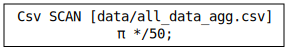

In [242]:
lf = pl.scan_csv(dataset, schema_overrides={'run_id': pl.String})
lf.show_graph()

In [243]:
rt_nodes = lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col("bandwidth") == '100 MHz')).select('round', 'run_id', 'nodes', 'downlink_latency', 'uplink_latency', 'eval_time', 'train_time').with_columns(pl.col("nodes").str.extract(r"(\d+)").cast(pl.Int32).alias("n_nodes"))
rt_nodes = rt_nodes.collect()

In [244]:
rt_nodes = rt_nodes.with_columns((pl.col('downlink_latency') + pl.col('uplink_latency') + pl.col('eval_time') + pl.col('train_time')).alias('round_time'))
agg = rt_nodes.group_by(["n_nodes", "round"]).agg(pl.col("round_time").first())
p90 = agg.group_by("n_nodes").agg(pl.col("round_time").quantile(0.9).alias("p90"))
agg = agg.join(p90, on="n_nodes").filter(pl.col("round_time") <= pl.col("p90"))
agg = agg.filter(pl.col("n_nodes") > 1)

In [245]:
groups = agg.sort('n_nodes').partition_by('n_nodes', maintain_order=True)
data = [g['round_time'].to_list() for g in groups]
labels = [f'{g['n_nodes'][0]} Nodes' for g in groups]

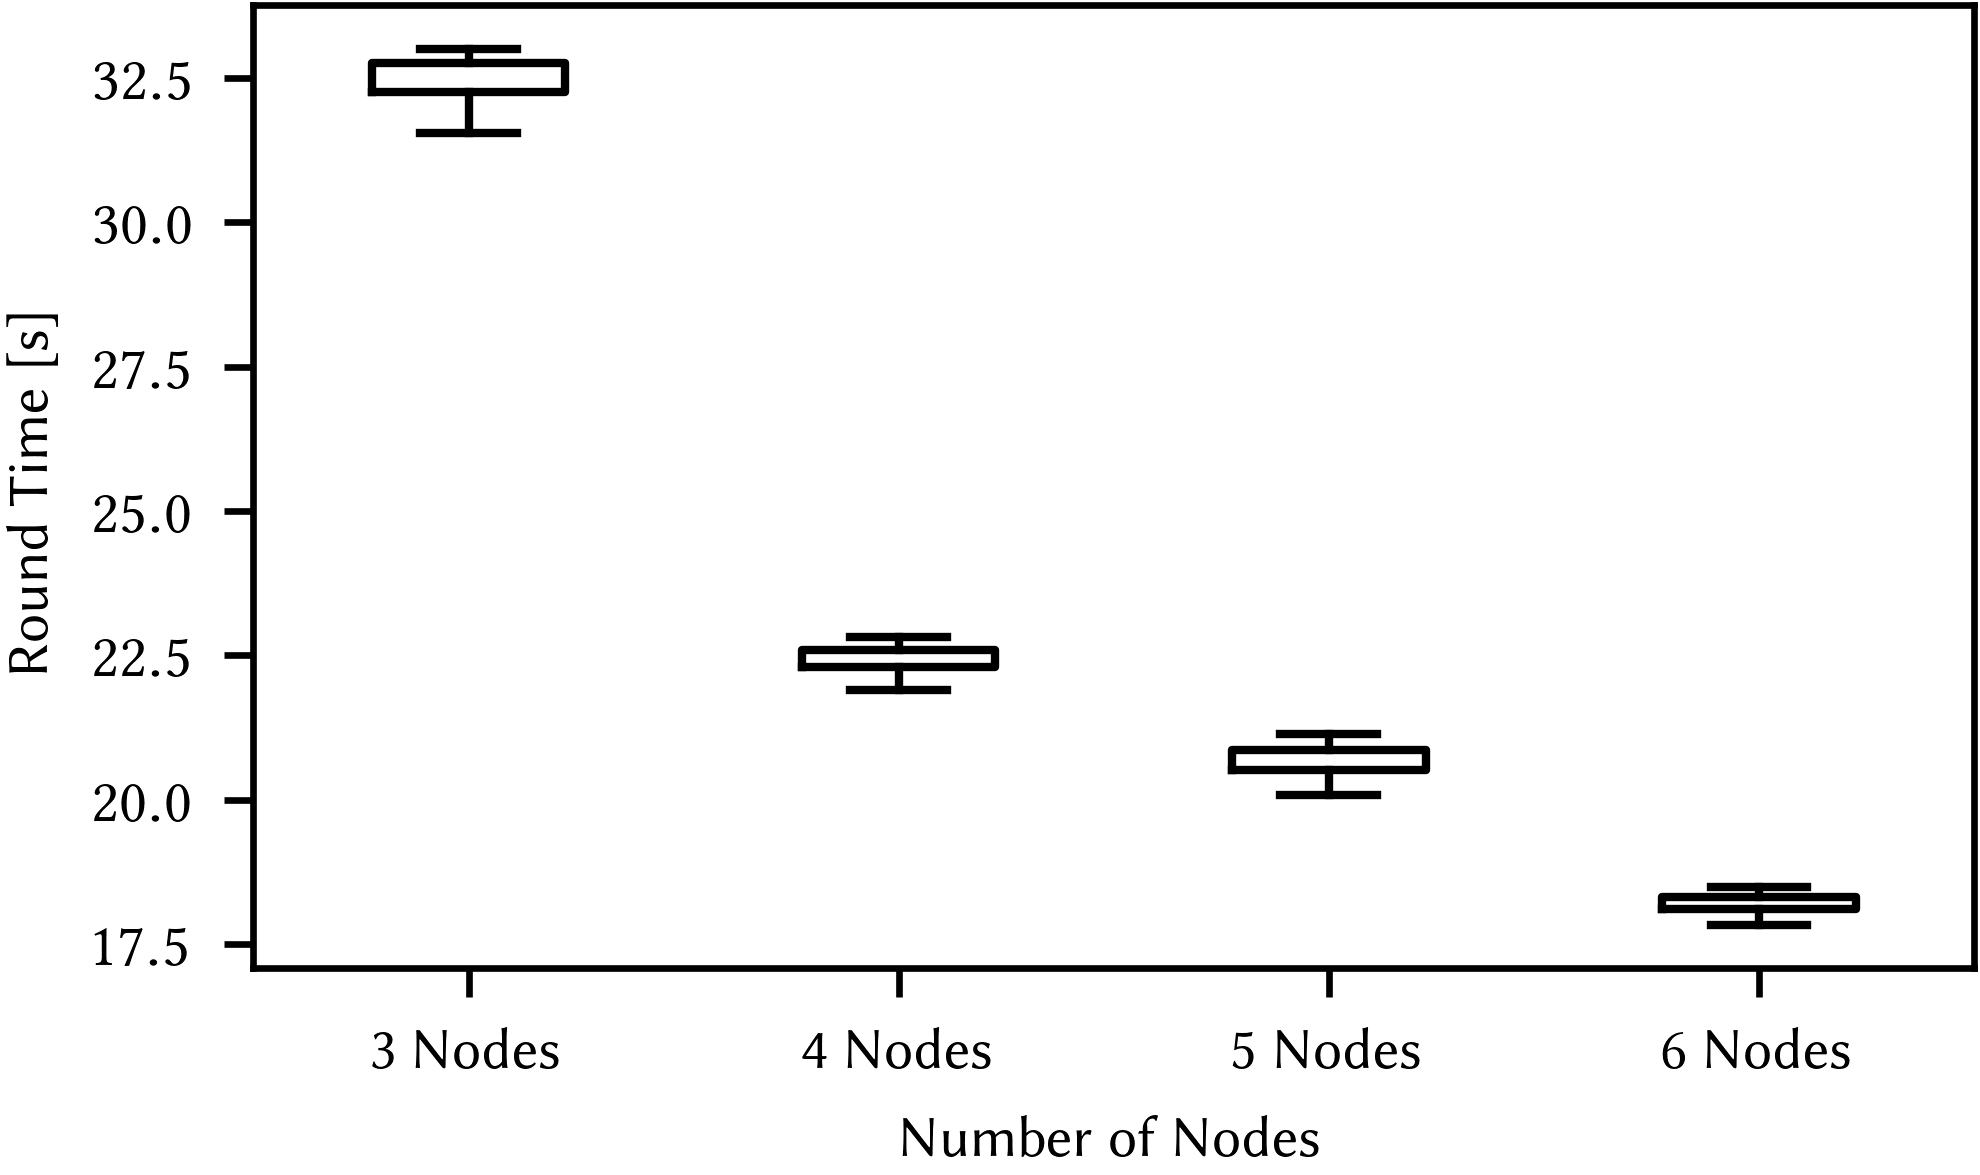

In [246]:
fig, ax = plt.subplots()
ax.boxplot(data, tick_labels=labels, medianprops=dict(visible=False), showfliers=False)
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Round Time [s]")
plt.tight_layout()
plt.savefig('round_time_box_nodes.pdf')
plt.show()

In [247]:
print('Round Time Stats')
for label, d in zip(labels, data):
    arr = np.array(d)
    print(f"{label}: mean={arr.mean():.2f} [s], median={np.median(arr):.2f} [s], std={arr.std():.2f} [s], min={arr.min():.2f} [s], max={arr.max():.2f} [s], n={len(arr)}")

Round Time Stats
3 Nodes: mean=32.49 [s], median=32.53 [s], std=0.32 [s], min=31.54 [s], max=33.01 [s], n=178
4 Nodes: mean=22.43 [s], median=22.44 [s], std=0.21 [s], min=21.89 [s], max=22.81 [s], n=177
5 Nodes: mean=20.68 [s], median=20.69 [s], std=0.23 [s], min=20.08 [s], max=21.13 [s], n=178
6 Nodes: mean=18.20 [s], median=18.19 [s], std=0.14 [s], min=17.83 [s], max=18.48 [s], n=178


### Communication time per node for 100 MHz, 7:2 TDD, Dirichlet, 2x2 MIMO
##### Change the filter parameter to select other configurations

In [248]:
# Change this filter to select other configurations
comm_time_nodes = lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col("bandwidth") == '100 MHz')).select('round', 'run_id', 'nodes', 'downlink_latency', 'uplink_latency').with_columns(pl.col("nodes").str.extract(r"(\d+)").cast(pl.Int32).alias("n_nodes"))
comm_time_nodes = comm_time_nodes.collect()

In [249]:
comm_time_nodes = comm_time_nodes.with_columns((pl.col('downlink_latency') + pl.col('uplink_latency')).alias('comm_time'))
agg = comm_time_nodes.group_by(["n_nodes", "round"]).agg(pl.col("comm_time").first())
p90 = agg.group_by("n_nodes").agg(pl.col("comm_time").quantile(0.99).alias("p90"))
agg = agg.join(p90, on="n_nodes").filter(pl.col("comm_time") <= pl.col("p90"))
agg = agg.filter(pl.col("n_nodes") > 1)

In [250]:
groups = agg.sort('n_nodes').partition_by('n_nodes', maintain_order=True)
data = [g['comm_time'].to_list() for g in groups]
labels = [f'{g['n_nodes'][0]} Nodes' for g in groups]

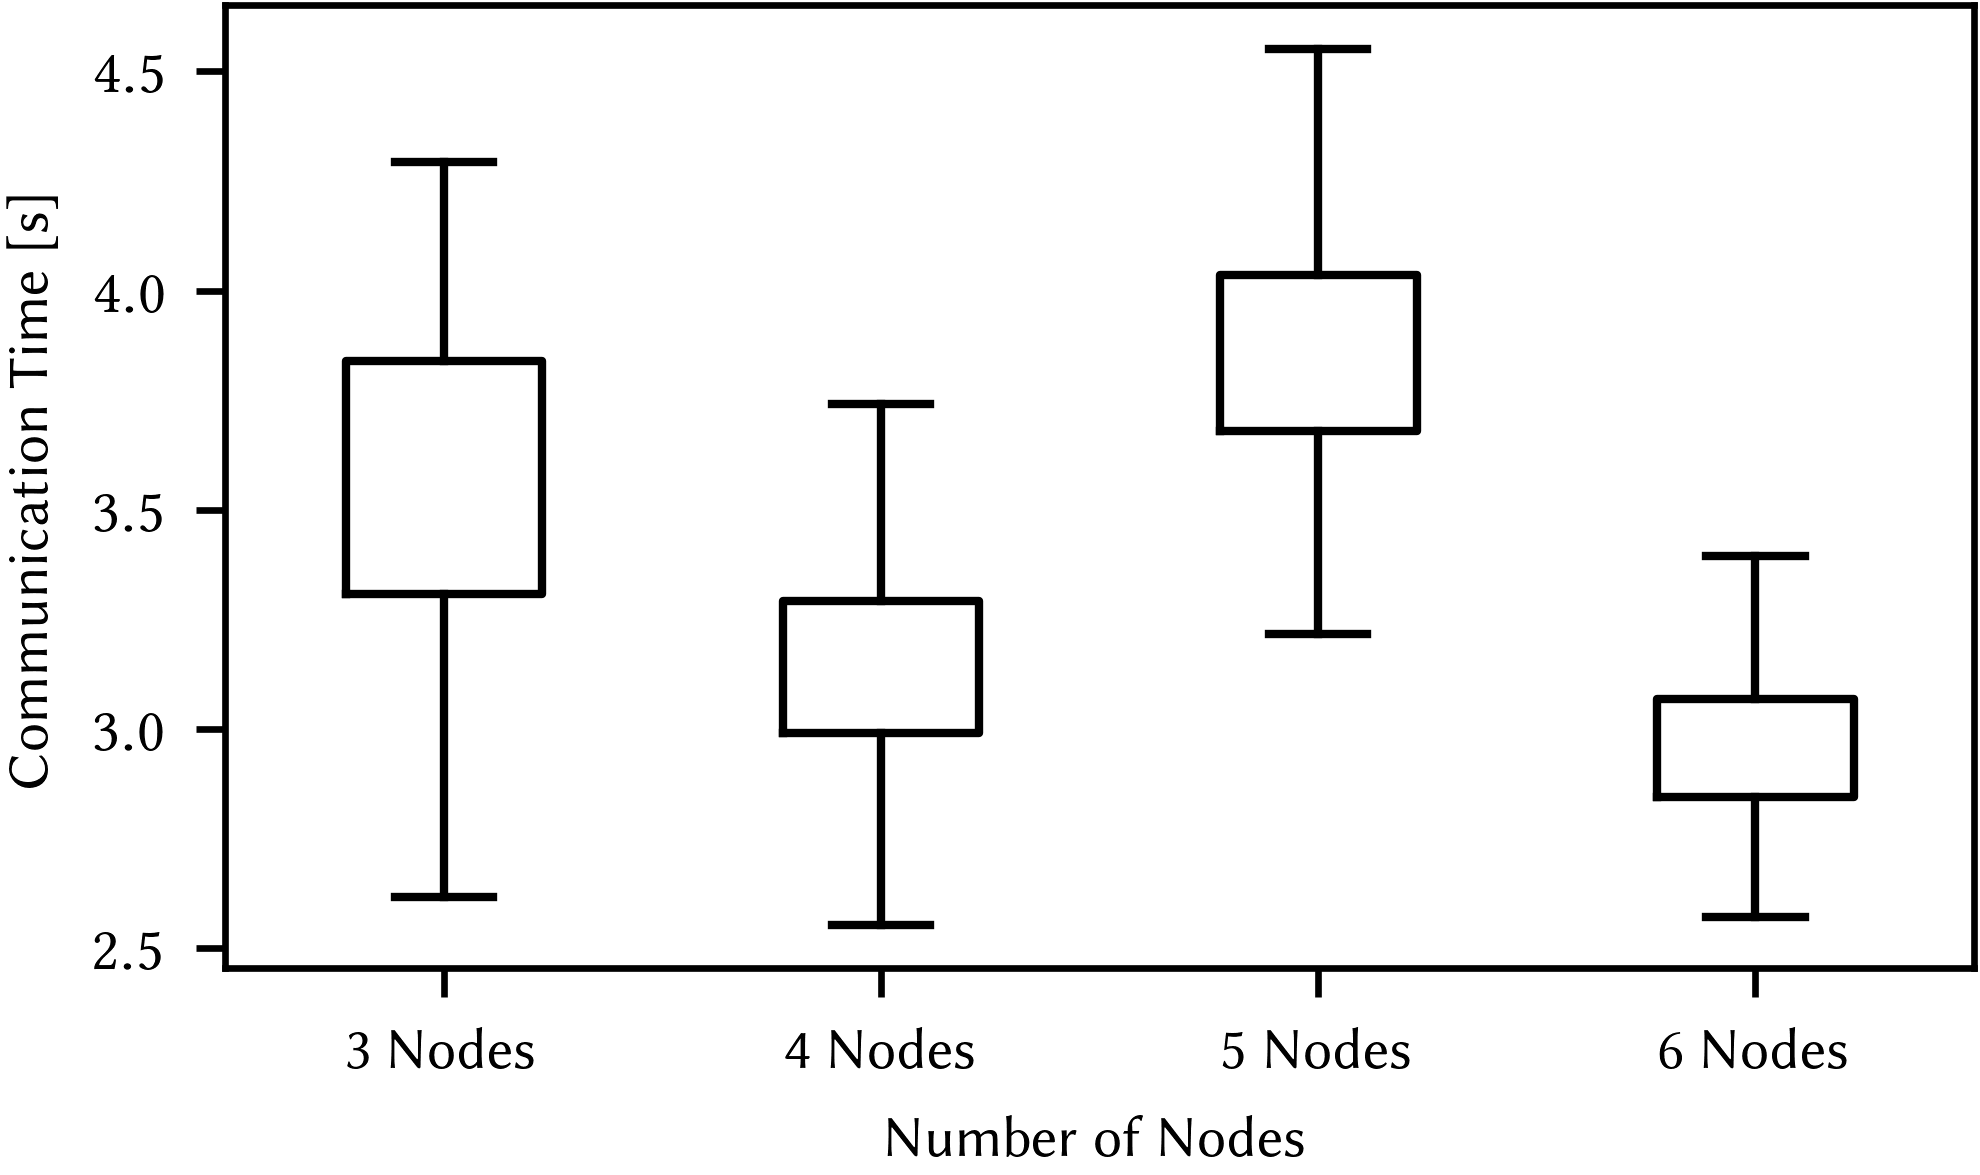

In [251]:
fig, ax = plt.subplots()
ax.boxplot(data, tick_labels=labels, medianprops=dict(visible=False), showfliers=False)
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Communication Time [s]")
plt.tight_layout()
plt.savefig('comm_time_box_nodes.pdf')
plt.show()

In [252]:
print('Comm Time Stats')
for label, d in zip(labels, data):
    arr = np.array(d)
    print(f"{label}: mean={arr.mean():.2f} [s], median={np.median(arr):.2f} [s], std={arr.std():.2f} [s], min={arr.min():.2f} [s], max={arr.max():.2f} [s], n={len(arr)}")

Comm Time Stats
3 Nodes: mean=3.58 [s], median=3.61 [s], std=0.34 [s], min=2.62 [s], max=4.29 [s], n=196
4 Nodes: mean=3.15 [s], median=3.15 [s], std=0.26 [s], min=2.55 [s], max=3.87 [s], n=195
5 Nodes: mean=3.86 [s], median=3.85 [s], std=0.26 [s], min=3.22 [s], max=4.57 [s], n=196
6 Nodes: mean=2.97 [s], median=2.93 [s], std=0.18 [s], min=2.57 [s], max=3.50 [s], n=196


### Uplink/Downlink Time per number of nodes
##### Change the filter parameter to select other configurations


In [253]:
# Change this filter to select other configurations
ul_dl_times = lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col("bandwidth") == '100 MHz')).select('round', 'run_id', 'nodes', 'downlink_latency', 'uplink_latency').with_columns(pl.col("nodes").str.extract(r"(\d+)").cast(pl.Int32).alias("n_nodes"))
ul_dl_times = ul_dl_times.collect()

In [254]:
agg = ul_dl_times.group_by(['n_nodes', 'round']).agg(pl.col('downlink_latency').first(), pl.col('uplink_latency').first()).filter(pl.col('n_nodes') > 1).sort('n_nodes')

In [255]:
groups = agg.partition_by('n_nodes', maintain_order=True)
x = np.arange(len(groups))
width = 0.35

In [256]:
dl_data = [g['downlink_latency'].to_list() for g in groups]
ul_data = [g['uplink_latency'].to_list() for g in groups]
labels = [f'{g['n_nodes'][0]} Nodes' for g in groups]

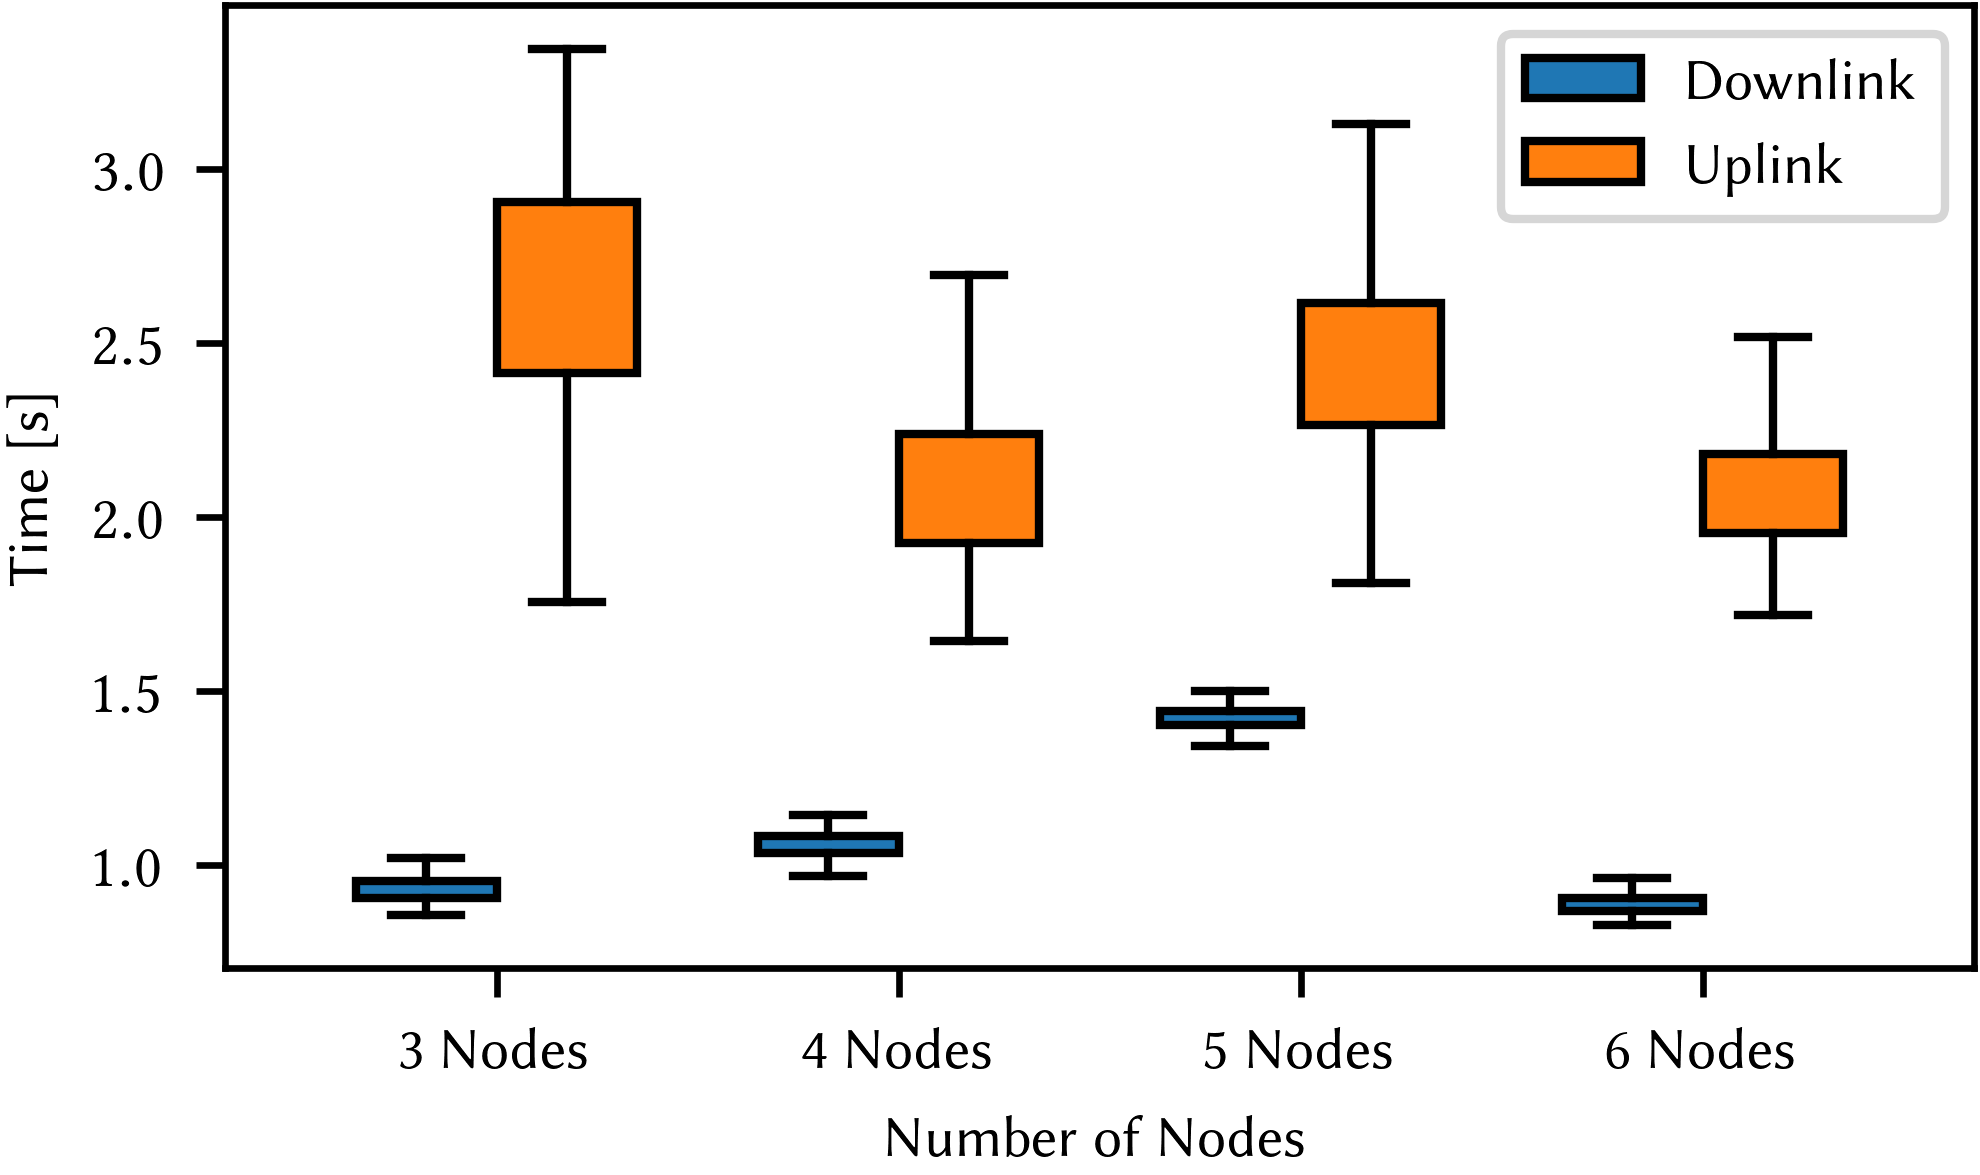

In [257]:
bp1 = plt.boxplot(dl_data, positions=x - width/2, widths=width, patch_artist=True, showfliers=False, medianprops=dict(visible=False))
bp2 = plt.boxplot(ul_data, positions=x + width/2, widths=width, patch_artist=True, showfliers=False, medianprops=dict(visible=False))

for box in bp1["boxes"]: box.set_facecolor("tab:blue")
for box in bp2["boxes"]: box.set_facecolor("tab:orange")

plt.xticks(x, labels)
plt.xlabel("Number of Nodes")
plt.ylabel("Time [s]")
plt.legend([bp1["boxes"][0], bp2["boxes"][0]], ["Downlink", "Uplink"])
plt.tight_layout()
plt.savefig('ul_dl_time.pdf')
plt.show()

In [258]:
for label, dl, ul in zip(labels, dl_data, ul_data):
    dl_arr, ul_arr = np.array(dl), np.array(ul)
    print(f"{label}:")
    print(f"  Downlink: mean={dl_arr.mean():.2f}, median={np.median(dl_arr):.2f}, std={dl_arr.std():.2f}, min={dl_arr.min():.2f}, max={dl_arr.max():.2f}, n={len(dl_arr)}")
    print(f"  Uplink:   mean={ul_arr.mean():.2f}, median={np.median(ul_arr):.2f}, std={ul_arr.std():.2f}, min={ul_arr.min():.2f}, max={ul_arr.max():.2f}, n={len(ul_arr)}")

3 Nodes:
  Downlink: mean=0.94, median=0.93, std=0.07, min=0.86, max=1.35, n=198
  Uplink:   mean=2.64, median=2.67, std=0.34, min=1.75, max=3.35, n=198
4 Nodes:
  Downlink: mean=4.06, median=1.06, std=42.03, min=0.87, max=592.46, n=197
  Uplink:   mean=2.10, median=2.11, std=0.26, min=1.64, max=2.97, n=197
5 Nodes:
  Downlink: mean=1.43, median=1.42, std=0.04, min=1.31, max=1.67, n=198
  Uplink:   mean=2.44, median=2.41, std=0.28, min=1.81, max=3.65, n=198
6 Nodes:
  Downlink: mean=0.89, median=0.89, std=0.04, min=0.83, max=1.07, n=198
  Uplink:   mean=2.08, median=2.04, std=0.18, min=1.72, max=2.77, n=198


### Computation time per node
##### Change the filter parameter to select other configurations


In [259]:
comp_time = lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col("bandwidth") == '100 MHz')).select('round', 'run_id', 'nodes', 'eval_time', 'train_time').with_columns(pl.col("nodes").str.extract(r"(\d+)").cast(pl.Int32).alias("n_nodes"))
comp_time = comp_time.collect()

In [260]:
comp_time = comp_time.with_columns((pl.col('train_time') + pl.col('eval_time')).alias('comp_time'))
agg = comp_time.group_by(["n_nodes", "round"]).agg(pl.col("comp_time").first())
p90 = agg.group_by("n_nodes").agg(pl.col("comp_time").quantile(0.9).alias("p90"))
agg = agg.join(p90, on="n_nodes").filter(pl.col("comp_time") <= pl.col("p90"))
agg = agg.filter(pl.col("n_nodes") > 1)

In [261]:
groups = agg.sort('n_nodes').partition_by('n_nodes', maintain_order=True)
data = [g['comp_time'].to_list() for g in groups]
labels = [f'{g['n_nodes'][0]} Nodes' for g in groups]

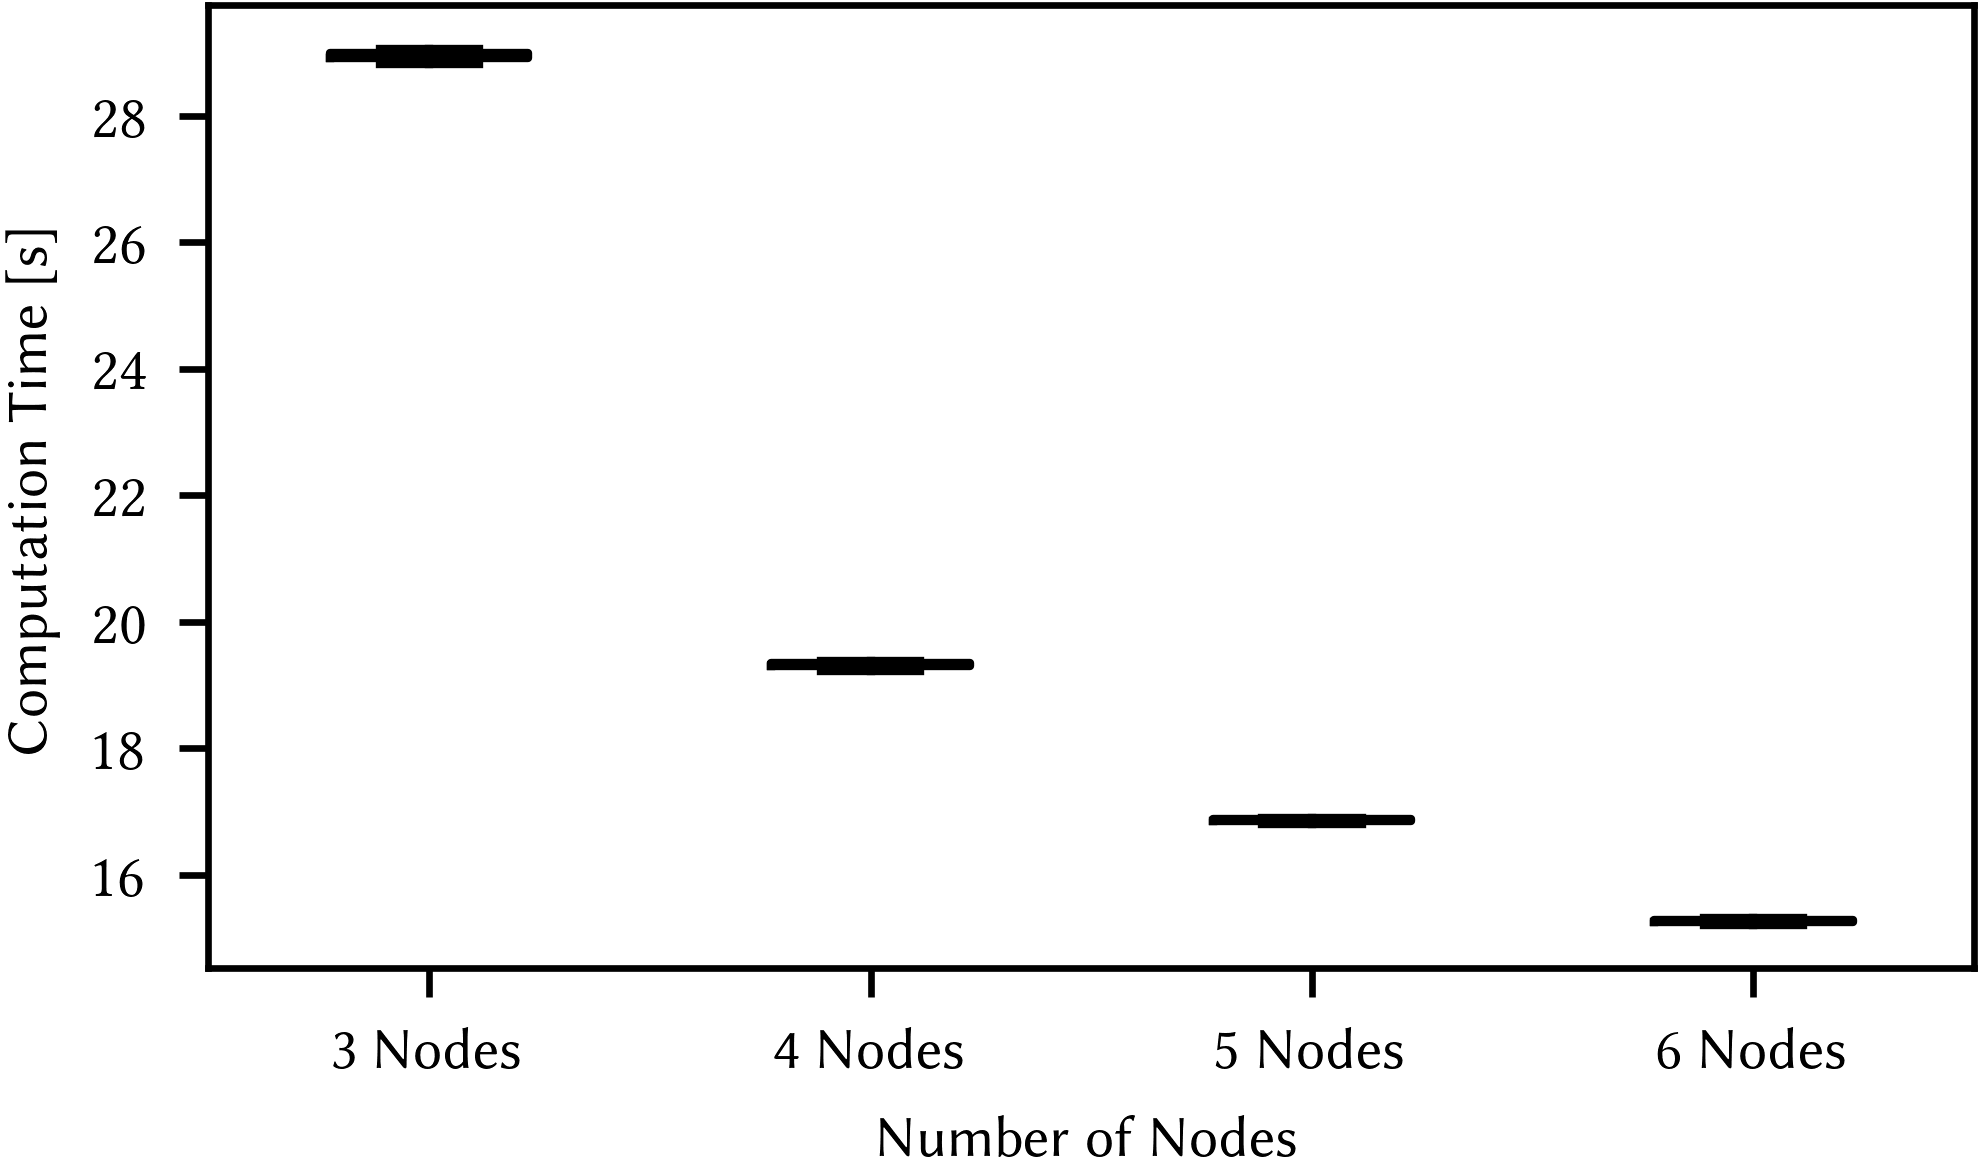

In [262]:
fig, ax = plt.subplots()
ax.boxplot(data, tick_labels=labels, medianprops=dict(visible=False), showfliers=False)
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Computation Time [s]")
plt.tight_layout()
plt.savefig('comp_time_box_nodes.pdf')
plt.show()

In [263]:
print('Comp Time Stats')
for label, d in zip(labels, data):
    arr = np.array(d)
    print(f"{label}: mean={arr.mean():.2f} [s], median={np.median(arr):.2f} [s], std={arr.std():.2f} [s], min={arr.min():.2f} [s], max={arr.max():.2f} [s], n={len(arr)}")

Comp Time Stats
3 Nodes: mean=28.95 [s], median=28.96 [s], std=0.05 [s], min=28.81 [s], max=29.06 [s], n=178
4 Nodes: mean=19.30 [s], median=19.32 [s], std=0.24 [s], min=16.22 [s], max=19.38 [s], n=177
5 Nodes: mean=16.86 [s], median=16.86 [s], std=0.03 [s], min=16.77 [s], max=16.90 [s], n=178
6 Nodes: mean=15.27 [s], median=15.27 [s], std=0.02 [s], min=15.21 [s], max=15.31 [s], n=178


### CDF of per round Comms straggler
##### Change settings in the filter

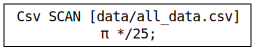

In [264]:
lf = pl.scan_csv(dataset_indiv, schema_overrides={'run_id': pl.String})
lf.show_graph()

In [265]:
straggler = lf.filter(
            (pl.col("rank") == "2x2") &
            (pl.col("tdd") == "7-2") &
            (pl.col("distribution") == "dirichlet") &
            (pl.col("network") == "wwan") &
            (pl.col("bandwidth") == '100 MHz') &
            (pl.col('nodes') == '6N')).select('cid', 'round', 'run_id', 'nodes', 'downlink_latency', 'uplink_latency', 'eval_time', 'train_time', 'num-examples', 'num-eval-examples')
straggler = straggler.collect()

In [266]:
median_train = straggler['num-examples'].median()
median_eval = straggler['num-eval-examples'].median()

In [267]:
per_round_cid = (
    straggler
    .with_columns(
        (pl.col("train_time") / pl.col("num-examples") * median_train).alias("train_time_norm"),
        (pl.col("eval_time") / pl.col("num-eval-examples") * median_eval).alias("eval_time_norm"),
    )
    .group_by(["round", "cid"])
    .agg(
        pl.col("downlink_latency").sum(),
        pl.col("uplink_latency").sum(),
        pl.col("train_time_norm").sum(),
        pl.col("eval_time_norm").sum()
    )
    .with_columns(
        (pl.col("downlink_latency") + pl.col("uplink_latency")).alias("total_comms"),
        (pl.col("train_time_norm") + pl.col("eval_time_norm")).alias("total_compute_norm"),
        (pl.col("downlink_latency") + pl.col("uplink_latency")+ pl.col("train_time_norm") + pl.col("eval_time_norm")).alias("total_time_norm"),
    )
)

In [268]:
per_round_cid

round,cid,downlink_latency,uplink_latency,train_time_norm,eval_time_norm,total_comms,total_compute_norm,total_time_norm
f64,i64,f64,f64,f64,f64,f64,f64,f64
114.0,2,0.799126,2.3522,12.929451,1.257901,3.151325,14.187352,17.338677
7.0,2,0.958742,2.21091,12.926883,1.249986,3.169652,14.176869,17.346521
23.0,1,0.844763,1.716013,12.793286,1.228975,2.560776,14.022261,16.583037
71.0,3,0.903061,3.122169,12.946106,1.250109,4.025229,14.196215,18.221444
99.0,5,0.93016,1.774793,12.948536,1.26563,2.704952,14.214166,16.919118
…,…,…,…,…,…,…,…,…
33.0,4,0.91924,2.484375,12.95775,1.293513,3.403615,14.251263,17.654878
145.0,5,0.923402,1.682909,12.882711,1.257525,2.606311,14.140236,16.746548
147.0,2,0.895914,2.192405,12.878967,1.245776,3.088319,14.124743,17.213062


### Overall (comp + comms) straggler CDF, shows the overall straggler comapred to mean and median

In [269]:
total_stragglers = (
    per_round_cid
    .sort("total_time_norm", descending=True)
    .group_by("round")
    .first()
)

straggler_vals = total_stragglers["total_time_norm"].sort().to_list()
average_vals = per_round_cid.group_by("round").agg(pl.col("total_time_norm").mean())["total_time_norm"].sort().to_list()
median_vals = per_round_cid.group_by("round").agg(pl.col("total_time_norm").median())["total_time_norm"].sort().to_list()

data = [straggler_vals, average_vals, median_vals]
labels = ['Straggler (max)', 'Mean', 'Median']

This is showing avg, median, and slowest total time

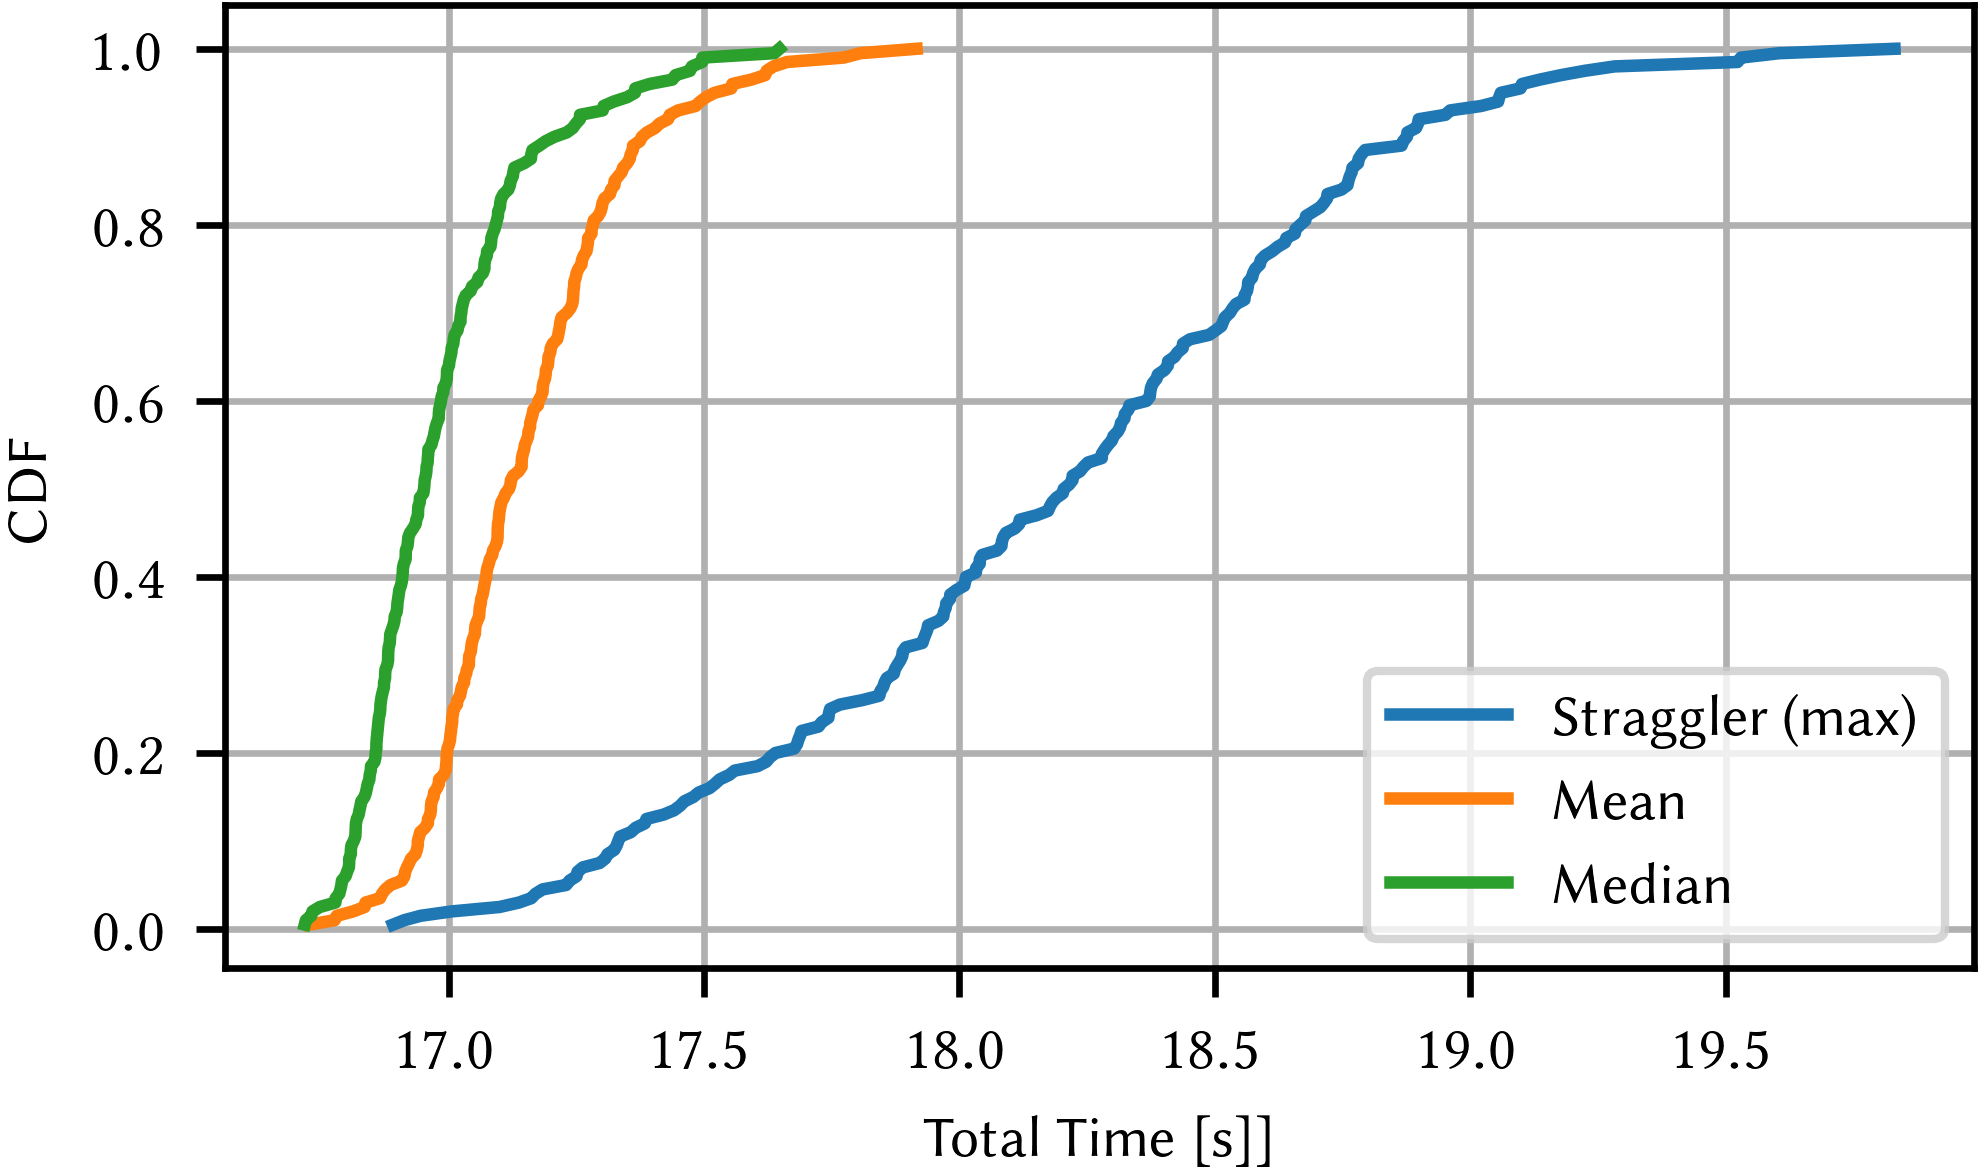

In [270]:
for vals, label in zip(data, labels):
    n = len(vals)
    plt.plot(vals, np.arange(1, n + 1) / n, label=label)

plt.xlabel("Total Time [s]]")
plt.ylabel("CDF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('cdf_straggler.pdf')
plt.show()

### Communication time straggler CDF, shows the overall straggler comapred to mean and median. This is normed to examples trained and evaled on

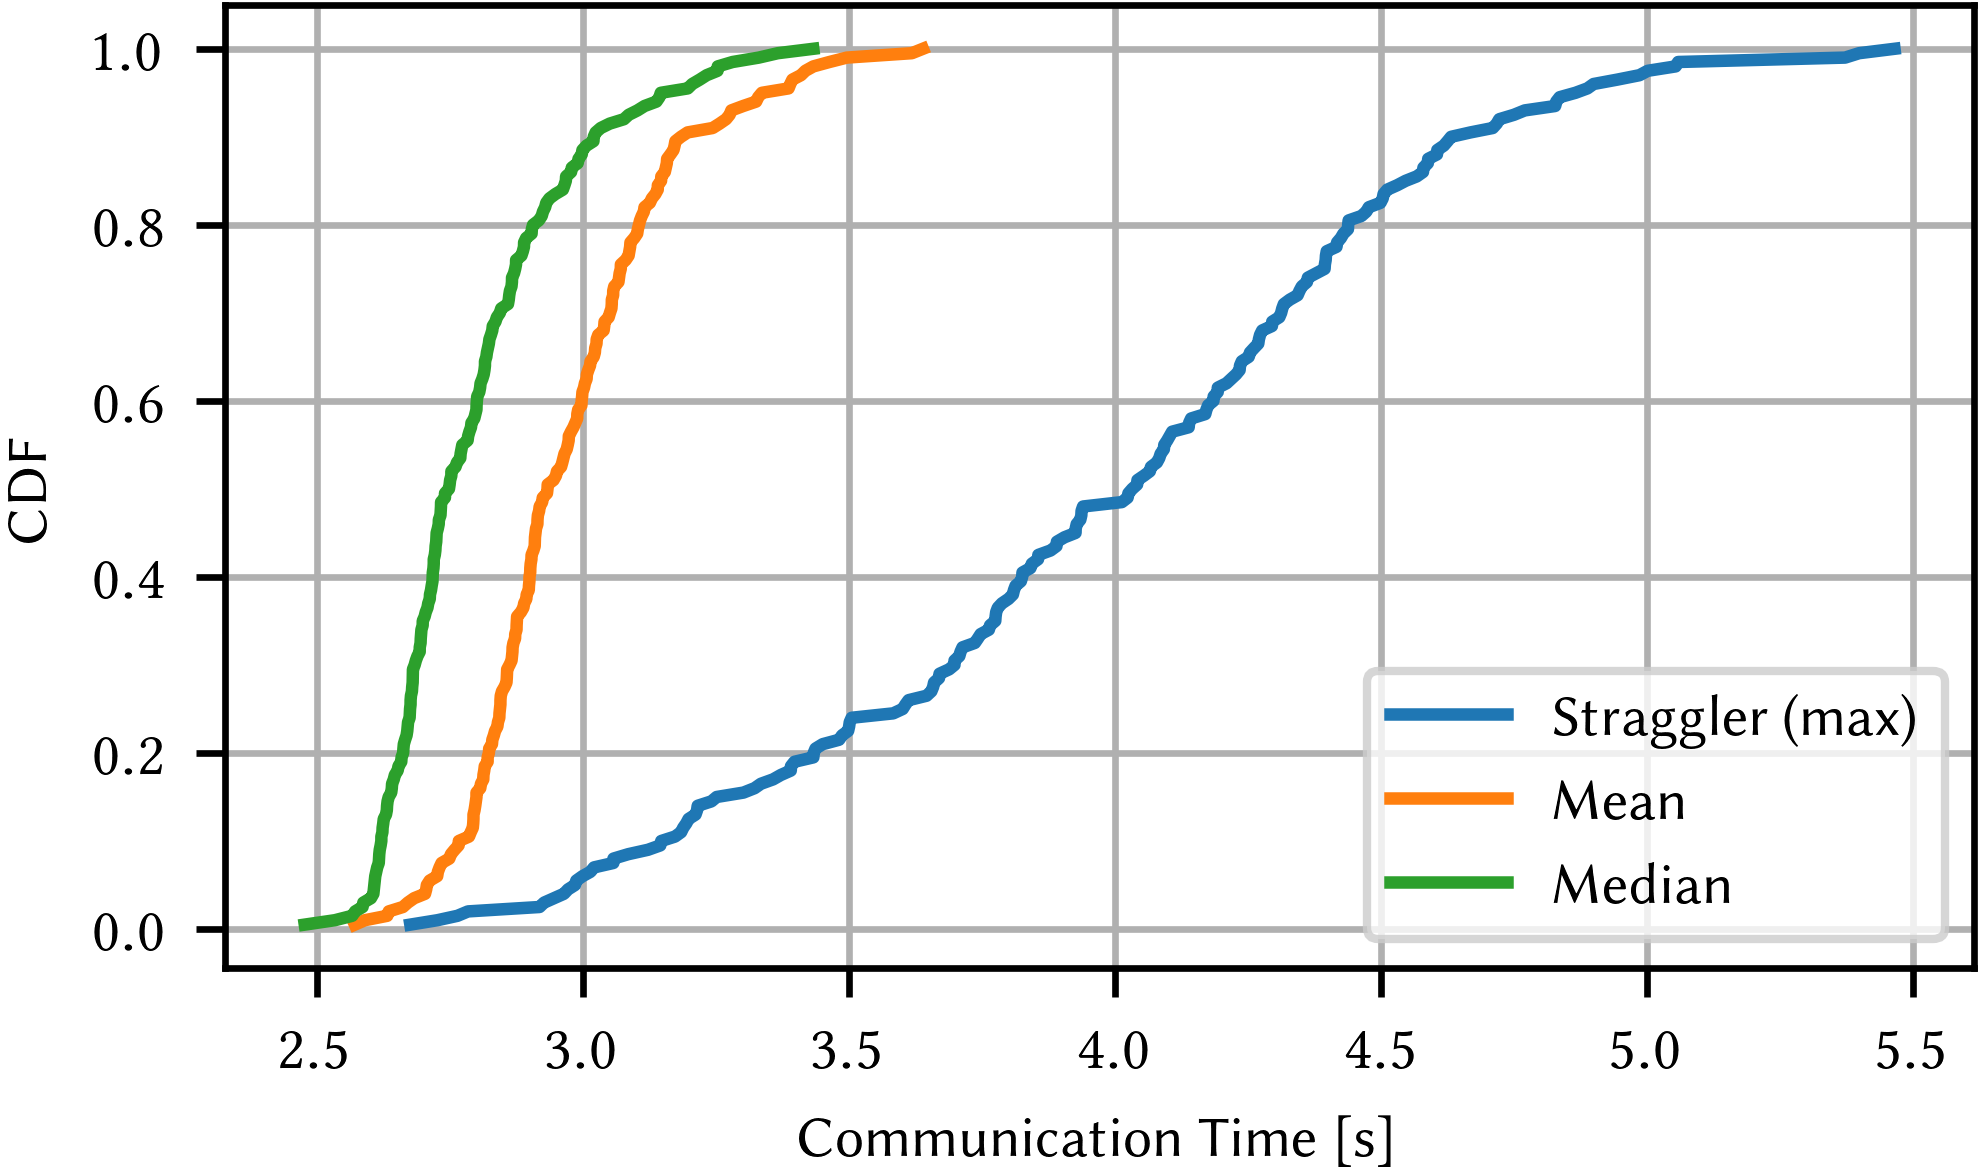

In [271]:
comms_stragglers = (
    per_round_cid
    .sort("total_comms", descending=True)
    .group_by("round")
    .first()
)

straggler_vals = total_stragglers["total_comms"].sort().to_list()
average_vals = per_round_cid.group_by("round").agg(pl.col("total_comms").mean())["total_comms"].sort().to_list()
median_vals = per_round_cid.group_by("round").agg(pl.col("total_comms").median())["total_comms"].sort().to_list()

data = [straggler_vals, average_vals, median_vals]
labels = ['Straggler (max)', 'Mean', 'Median']



for vals, label in zip(data, labels):
    n = len(vals)
    plt.plot(vals, np.arange(1, n + 1) / n, label=label)

plt.xlabel("Communication Time [s]")
plt.ylabel("CDF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('cdf_straggler_comms.pdf')
plt.show()

### Compute time straggler CDF, shows the overall straggler comapred to mean and median

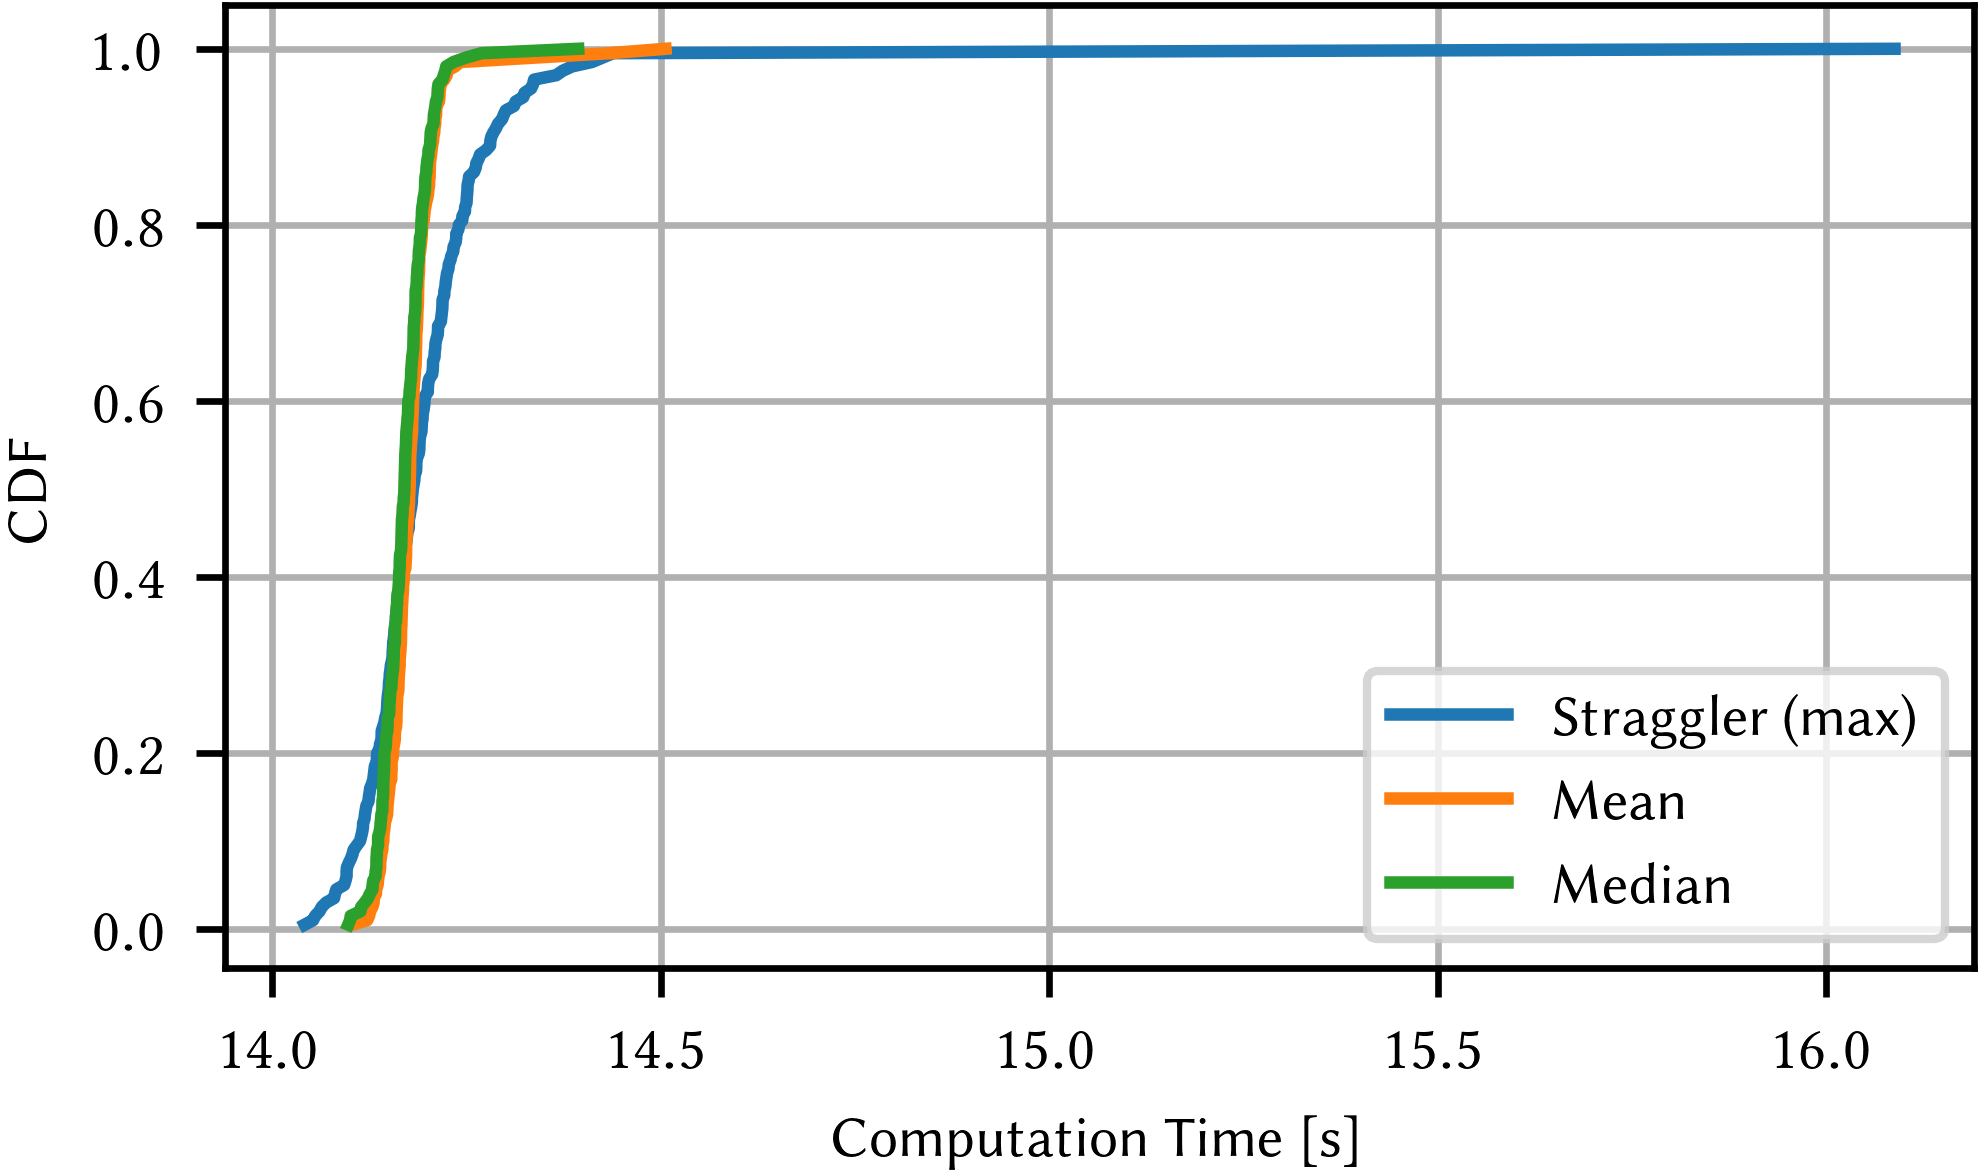

In [272]:
comms_stragglers = (
    per_round_cid
    .sort("total_compute_norm", descending=True)
    .group_by("round")
    .first()
)

straggler_vals = total_stragglers["total_compute_norm"].sort().to_list()
average_vals = per_round_cid.group_by("round").agg(pl.col("total_compute_norm").mean())["total_compute_norm"].sort().to_list()
median_vals = per_round_cid.group_by("round").agg(pl.col("total_compute_norm").median())["total_compute_norm"].sort().to_list()

data = [straggler_vals, average_vals, median_vals]
labels = ['Straggler (max)', 'Mean', 'Median']



for vals, label in zip(data, labels):
    n = len(vals)
    plt.plot(vals, np.arange(1, n + 1) / n, label=label)

plt.xlabel("Computation Time [s]")
plt.ylabel("CDF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('cdf_straggler_comp.pdf')
plt.show()

### Overall straggler bar plot.

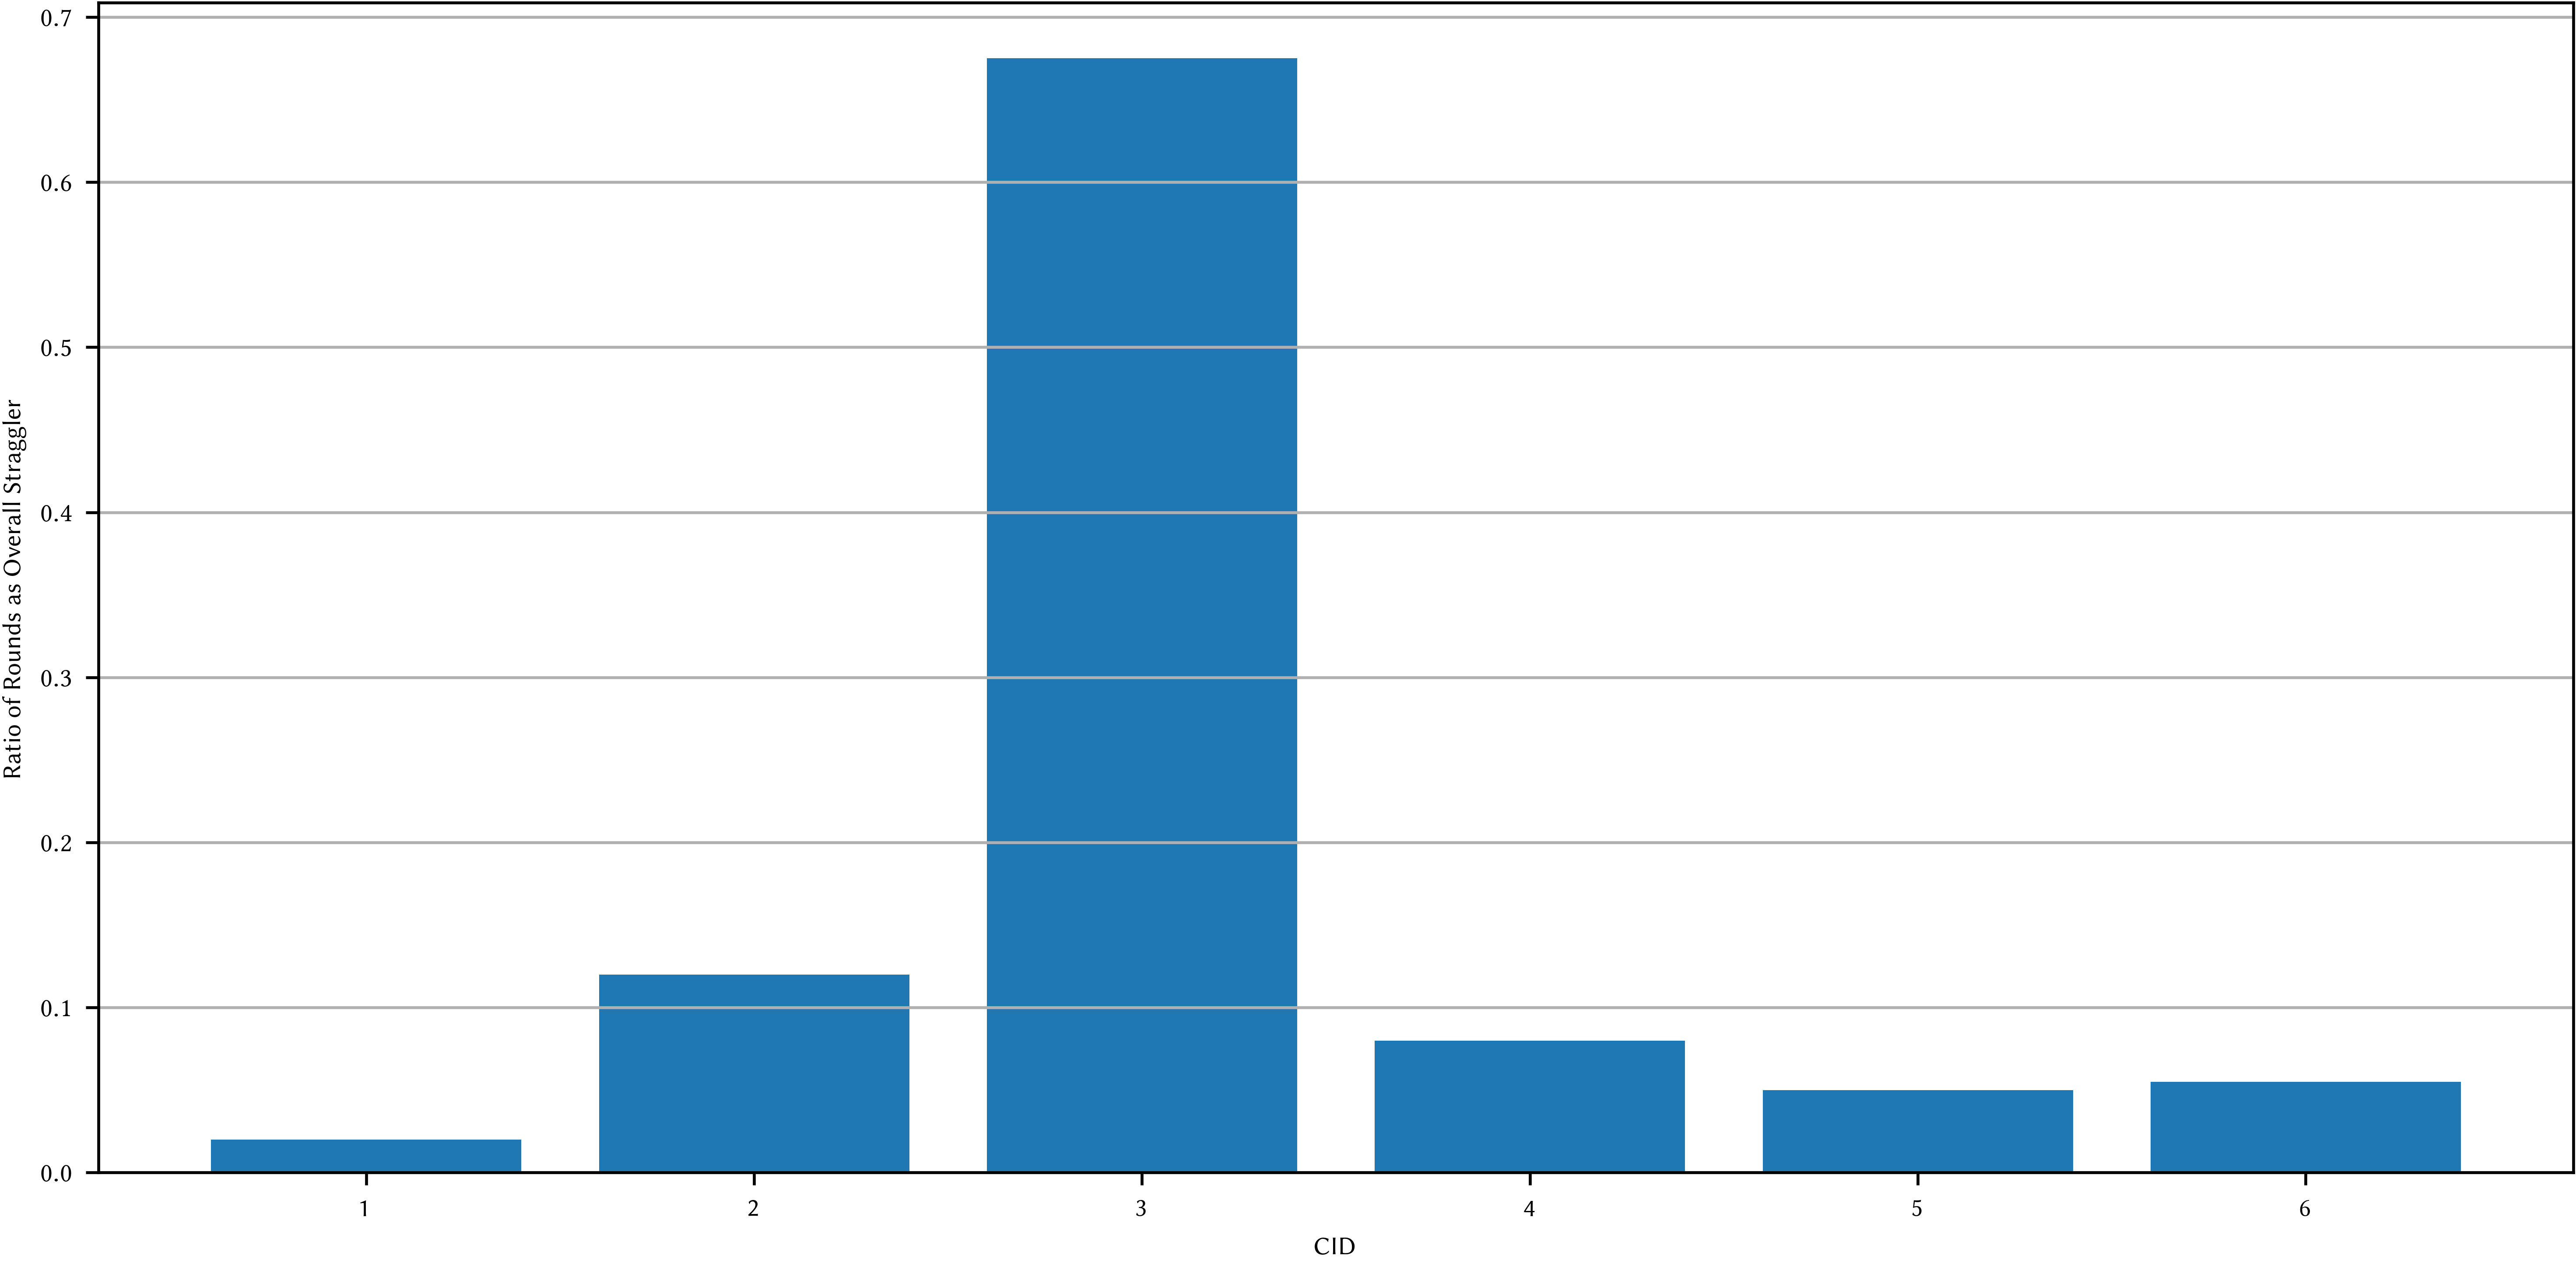

In [273]:
col = 'total_time_norm'
stragglers = per_round_cid.sort(col, descending=True).group_by("round").first()
counts = stragglers.group_by("cid").agg(pl.col("round").count().alias("n"))
total_rounds = stragglers["round"].n_unique()
ratios = counts.with_columns(
    (pl.col("n") / total_rounds).alias("ratio"),
    pl.col("cid").cast(pl.Int32),
).sort("cid")

plt.figure(figsize=(10, 5))
plt.bar(ratios["cid"].cast(str), ratios["ratio"])
plt.xlabel("CID")
plt.ylabel(f"Ratio of Rounds as Overall Straggler")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig('straggler_cid_bar_overall.pdf')
plt.show()

### Computation straggler bar plot.

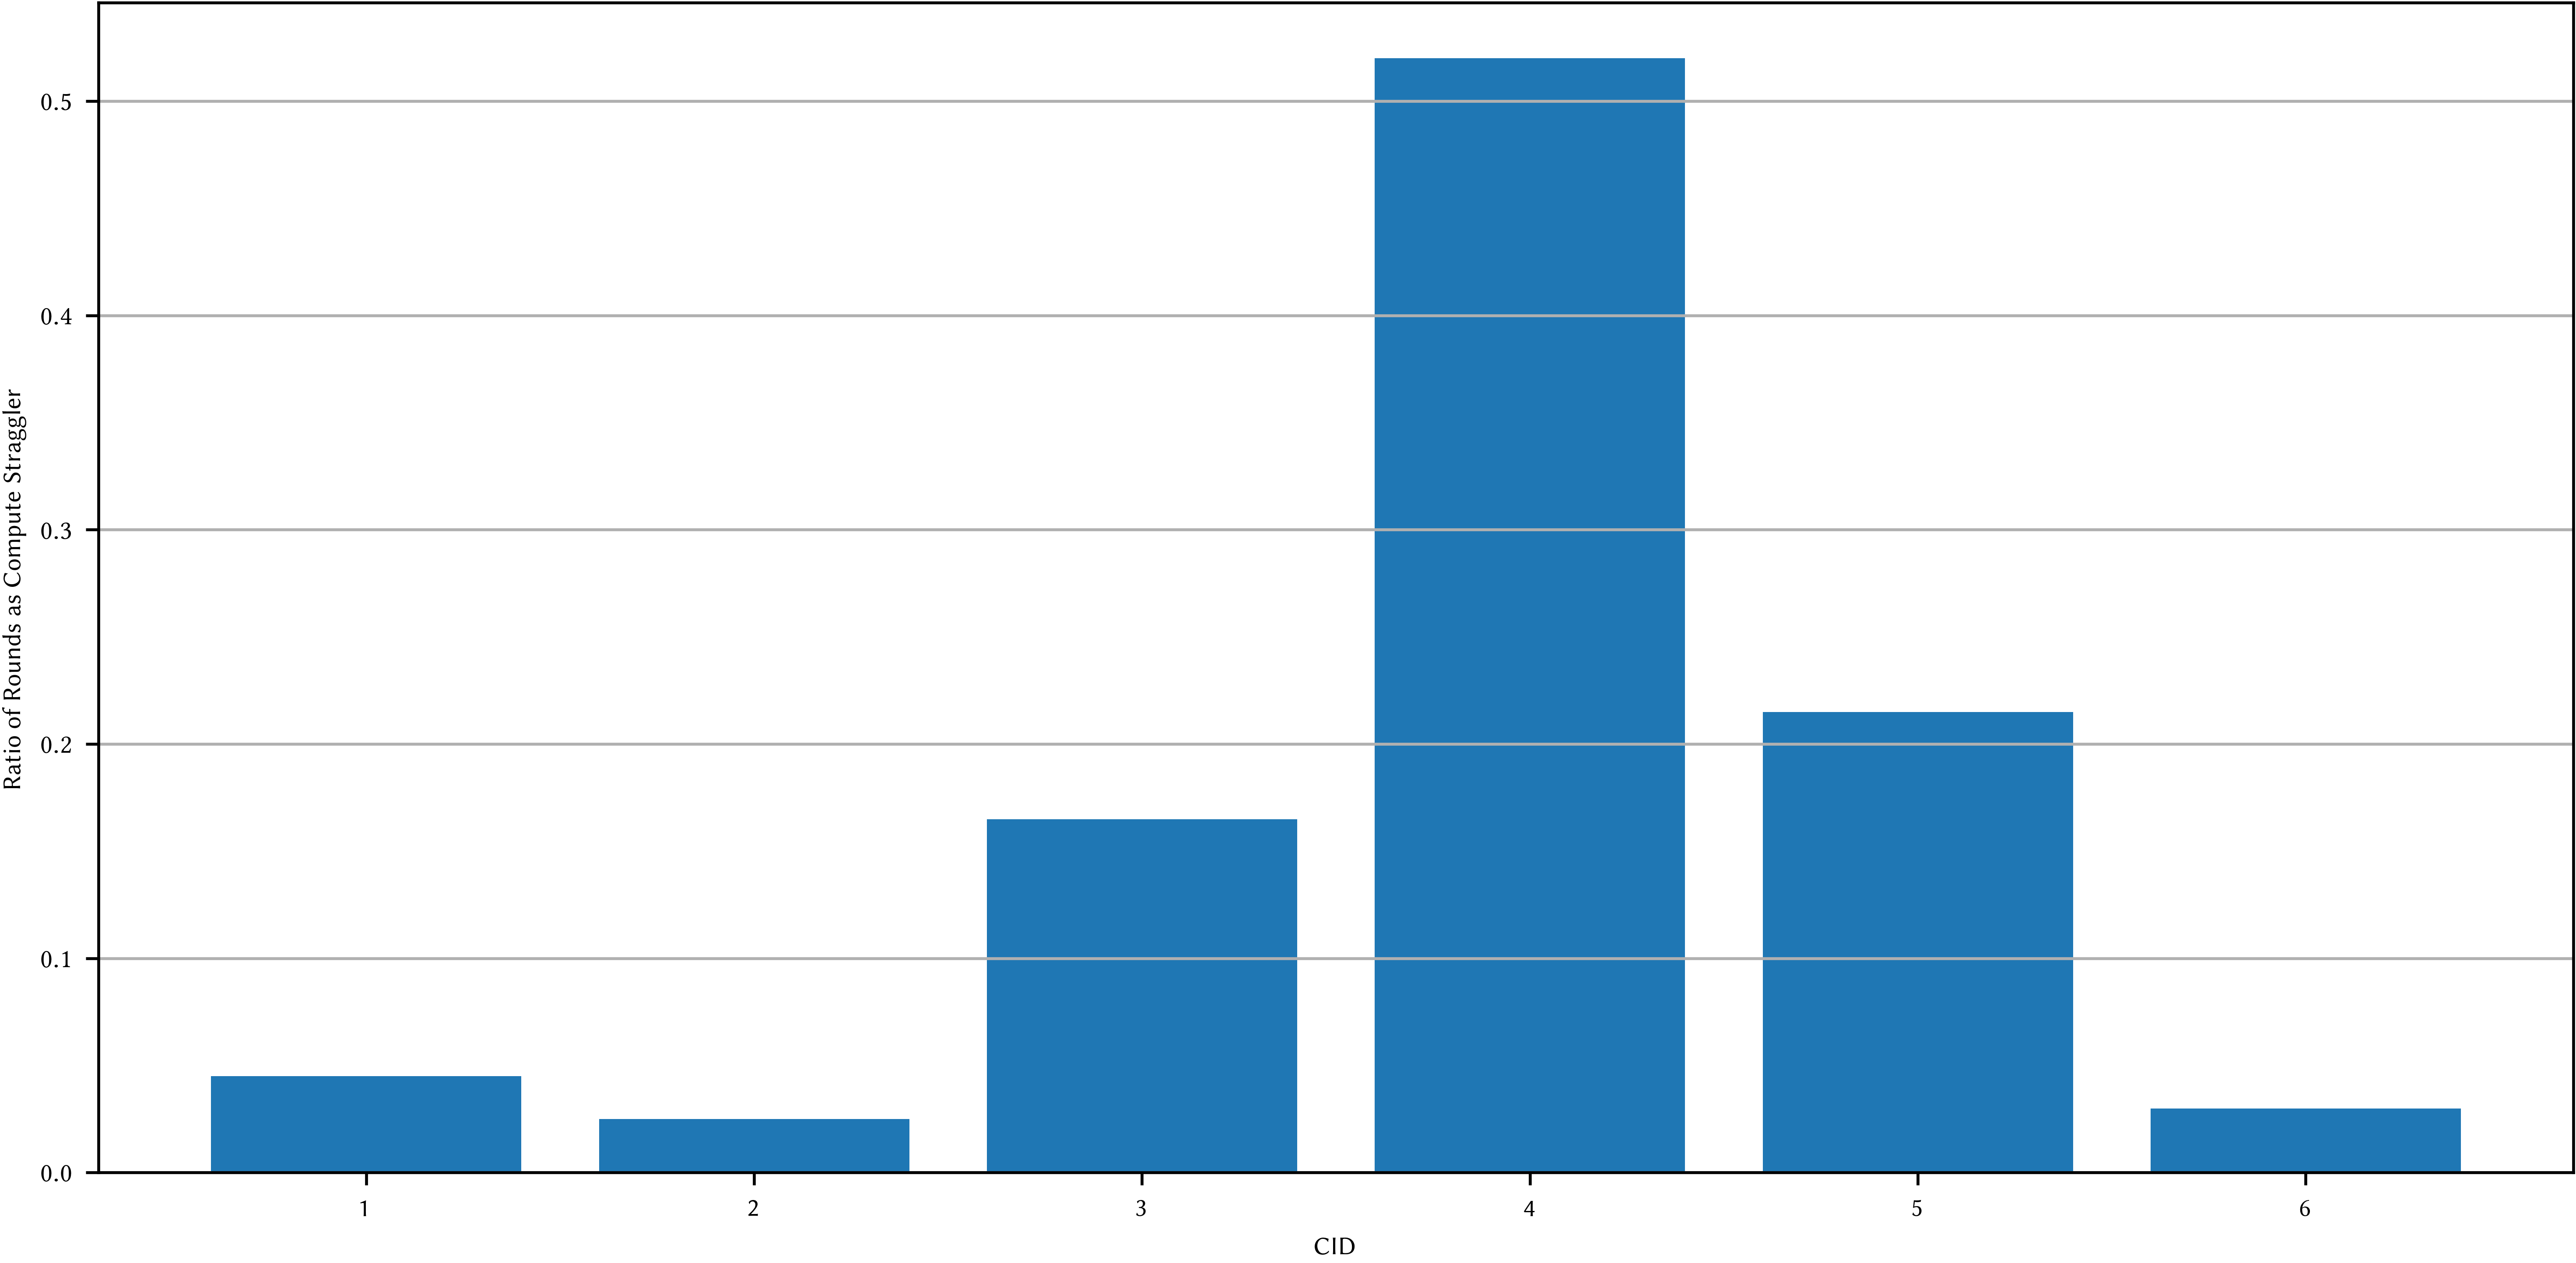

In [274]:
col = 'total_compute_norm'
stragglers = per_round_cid.sort(col, descending=True).group_by("round").first()
counts = stragglers.group_by("cid").agg(pl.col("round").count().alias("n"))
total_rounds = stragglers["round"].n_unique()
ratios = counts.with_columns(
    (pl.col("n") / total_rounds).alias("ratio"),
    pl.col("cid").cast(pl.Int32),
).sort("cid")

plt.figure(figsize=(10, 5))
plt.bar(ratios["cid"].cast(str), ratios["ratio"])
plt.xlabel("CID")
plt.ylabel(f"Ratio of Rounds as Compute Straggler")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig('straggler_cid_bar_compute.pdf')
plt.show()

#### Comms time straggler bar plot

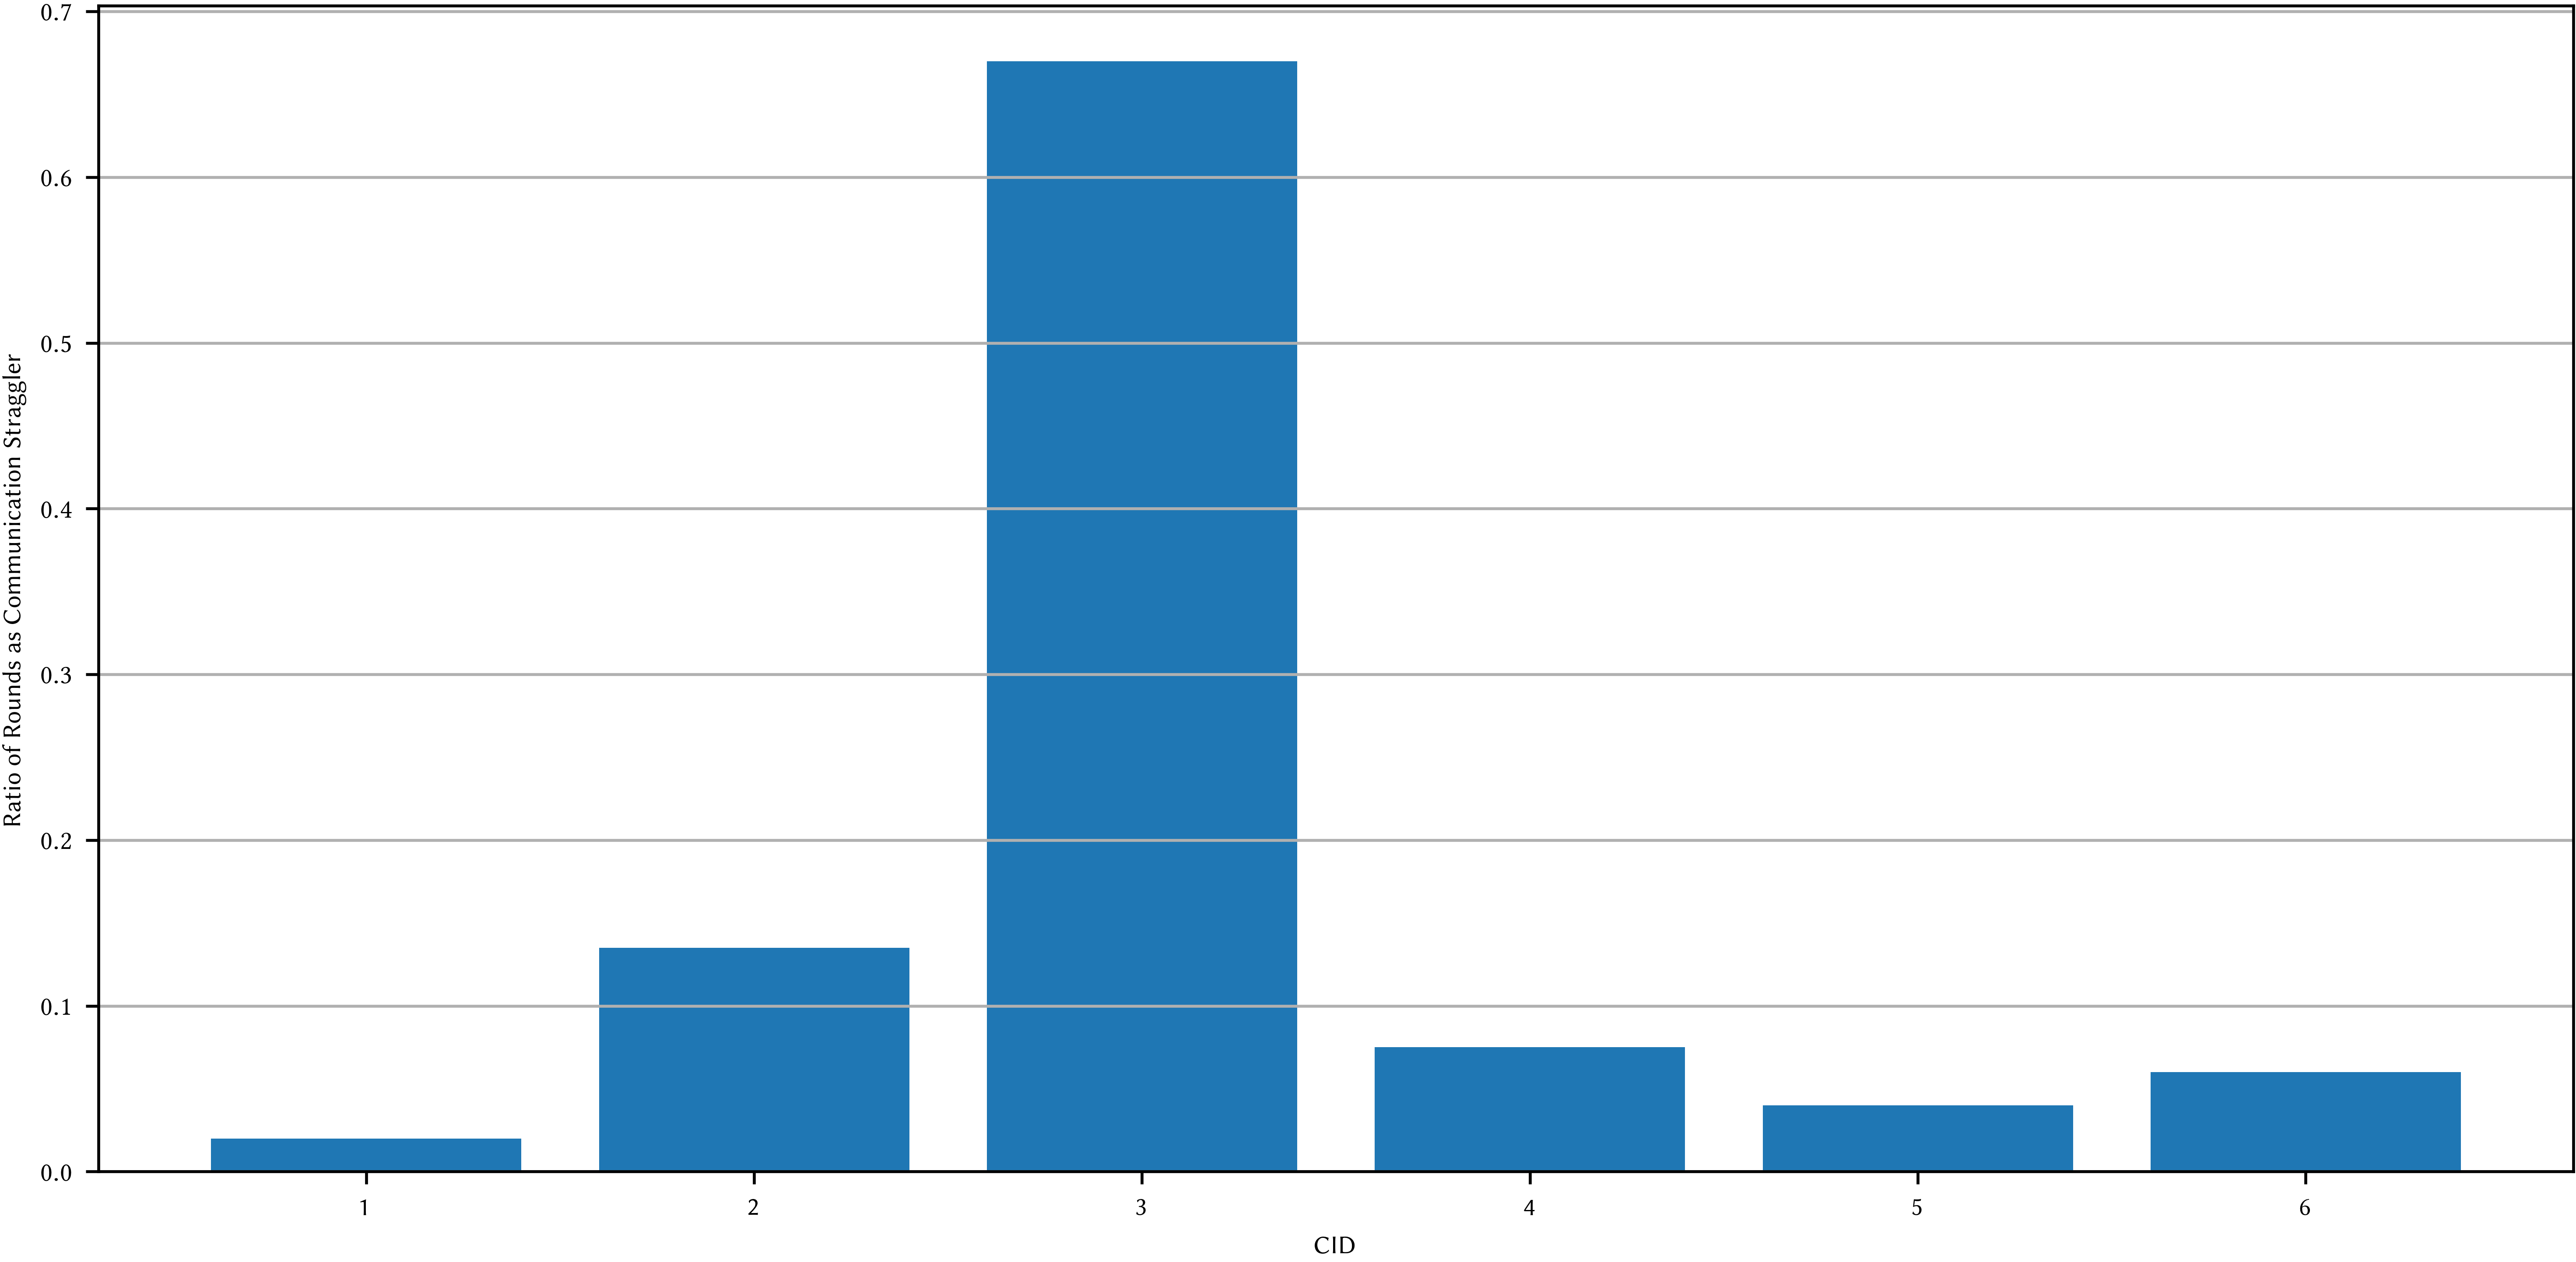

In [275]:
col = 'total_comms'
stragglers = per_round_cid.sort(col, descending=True).group_by("round").first()
counts = stragglers.group_by("cid").agg(pl.col("round").count().alias("n"))
total_rounds = stragglers["round"].n_unique()
ratios = counts.with_columns(
    (pl.col("n") / total_rounds).alias("ratio"),
    pl.col("cid").cast(pl.Int32),
).sort("cid")

plt.figure(figsize=(10, 5))
plt.bar(ratios["cid"].cast(str), ratios["ratio"])
plt.xlabel("CID")
plt.ylabel(f"Ratio of Rounds as Communication Straggler")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig('straggler_cid_bar_comms.pdf')
plt.show()

### Same data as the bar graphs but as cdf

#### Per CID CDF  per round straggler

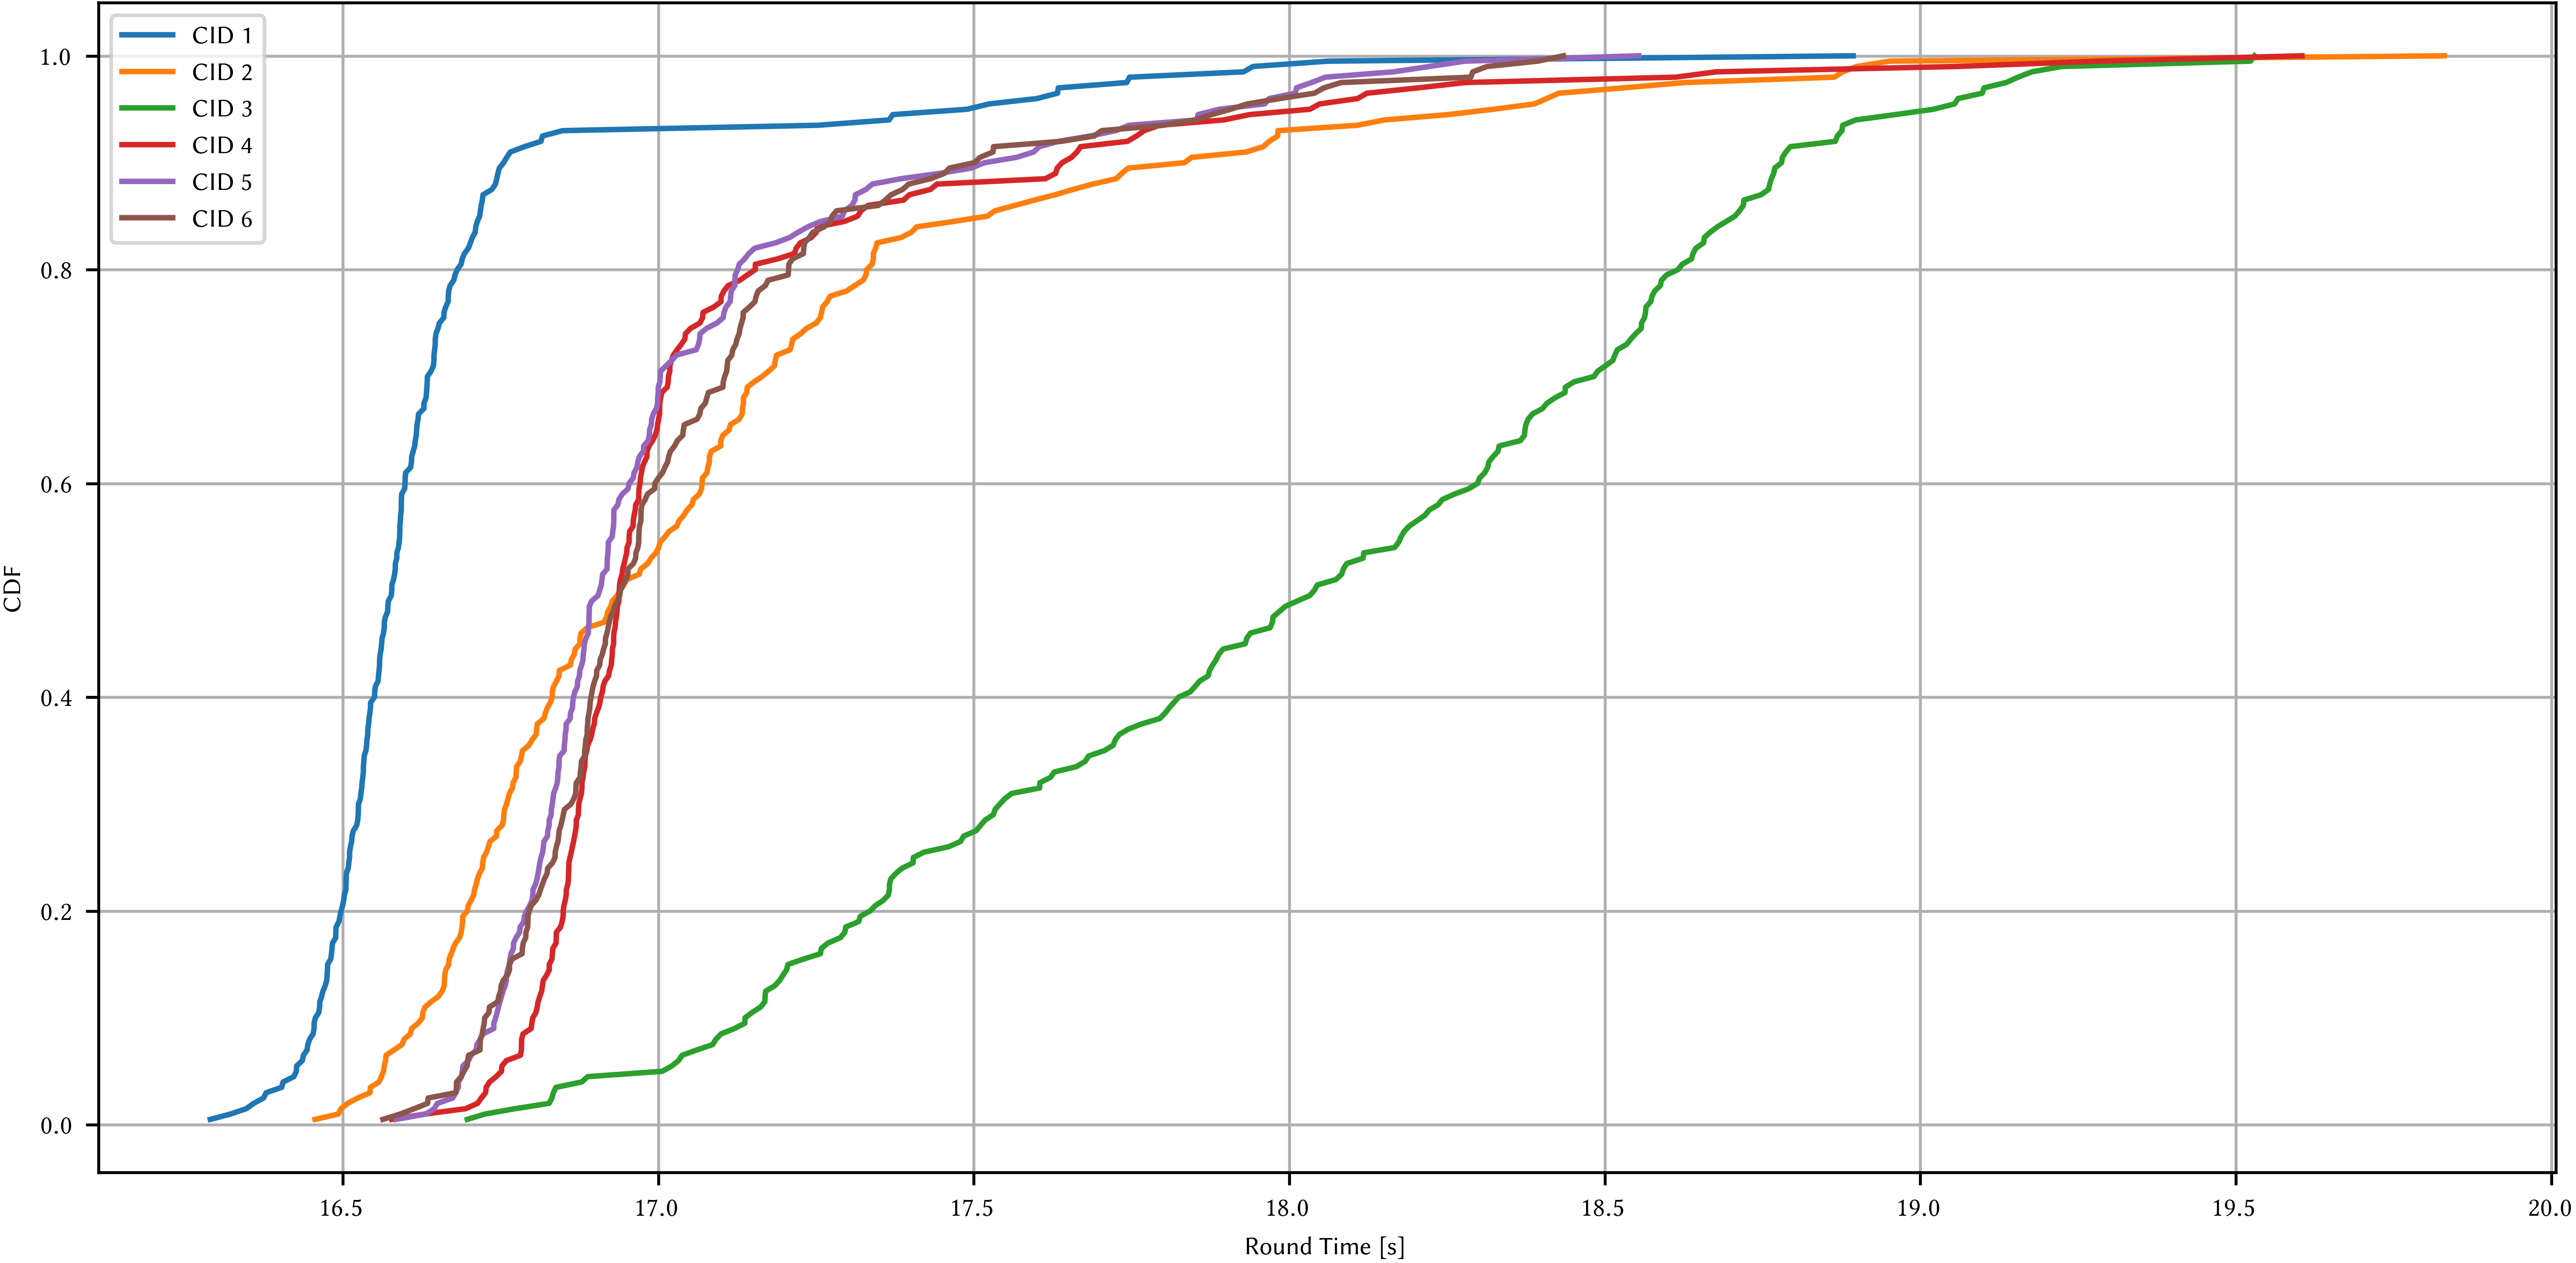

In [276]:
plt.figure(figsize=(10, 5))
for cid, group in per_round_cid.sort("cid").group_by("cid"):
    vals = group['total_time_norm'].sort().to_list()
    n = len(vals)
    plt.plot(vals, np.arange(1, n + 1) / n, label=f"CID {cid[0]}")

plt.xlabel(f"Round Time [s]")
plt.ylabel("CDF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("straggler_total_time_cdf_per_cid.pdf")
plt.show()

#### Per CID CDF per round compute (normed to examples)

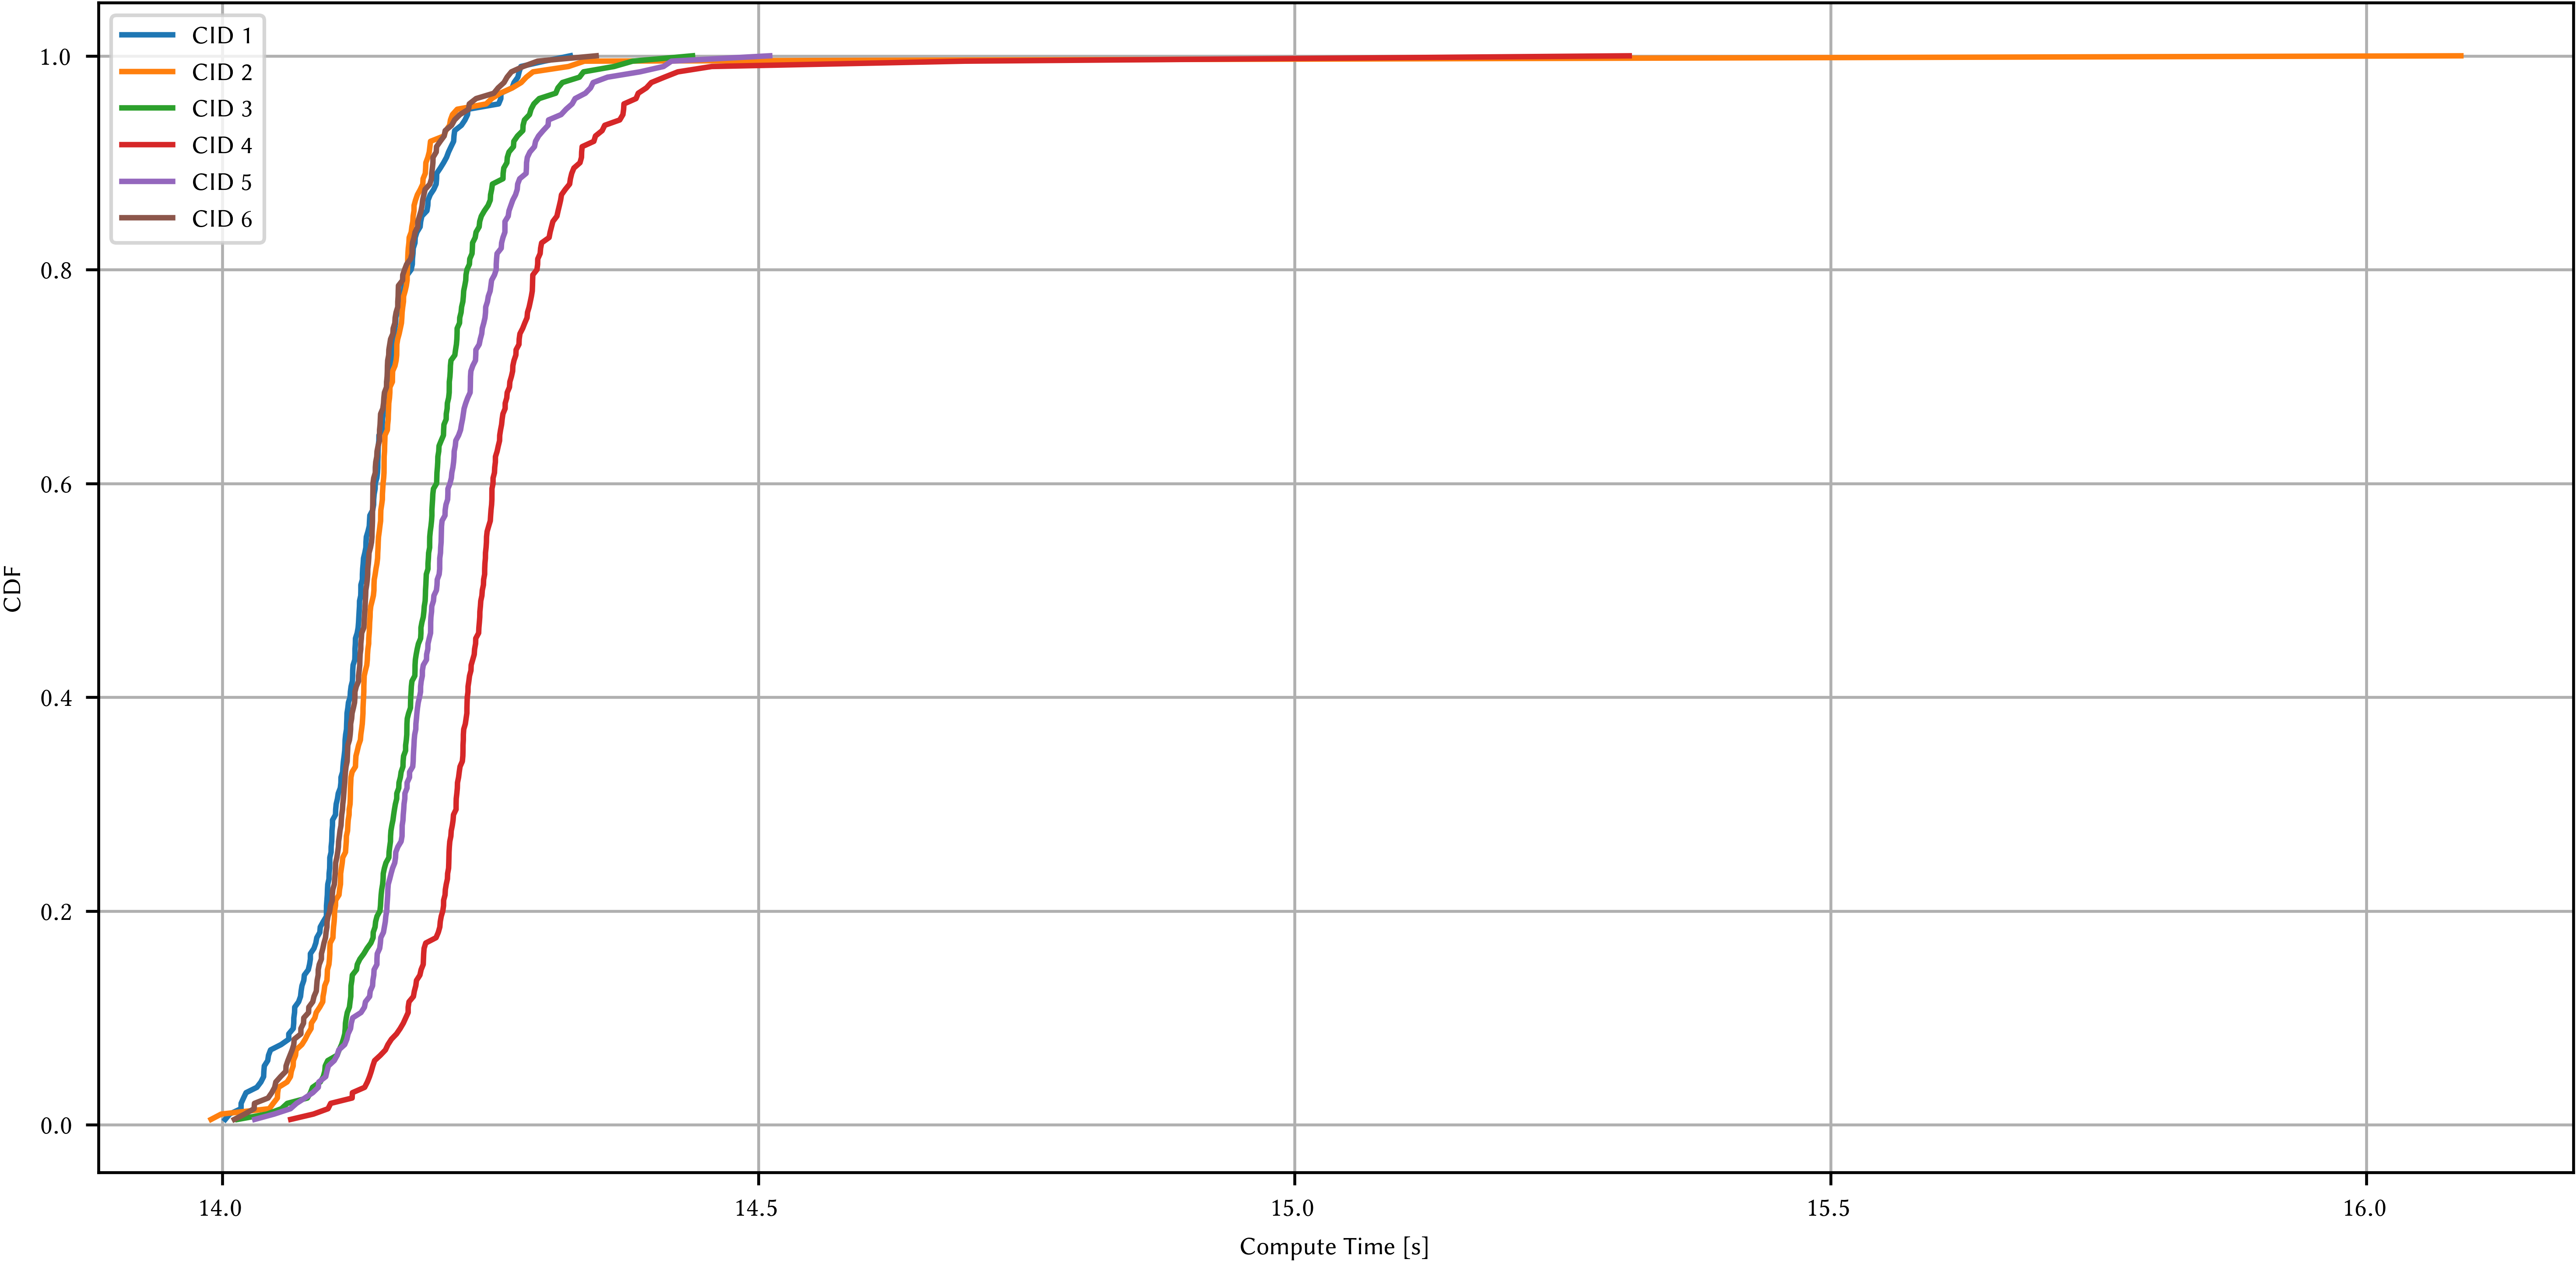

In [277]:
plt.figure(figsize=(10, 5))
for cid, group in per_round_cid.sort("cid").group_by("cid"):
    vals = group['total_compute_norm'].sort().to_list()
    n = len(vals)
    plt.plot(vals, np.arange(1, n + 1) / n, label=f"CID {cid[0]}")

plt.xlabel(f"Compute Time [s]")
plt.ylabel("CDF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("straggler_compute_cdf_per_cid.pdf")
plt.show()

#### Per CID CDF per round communication time

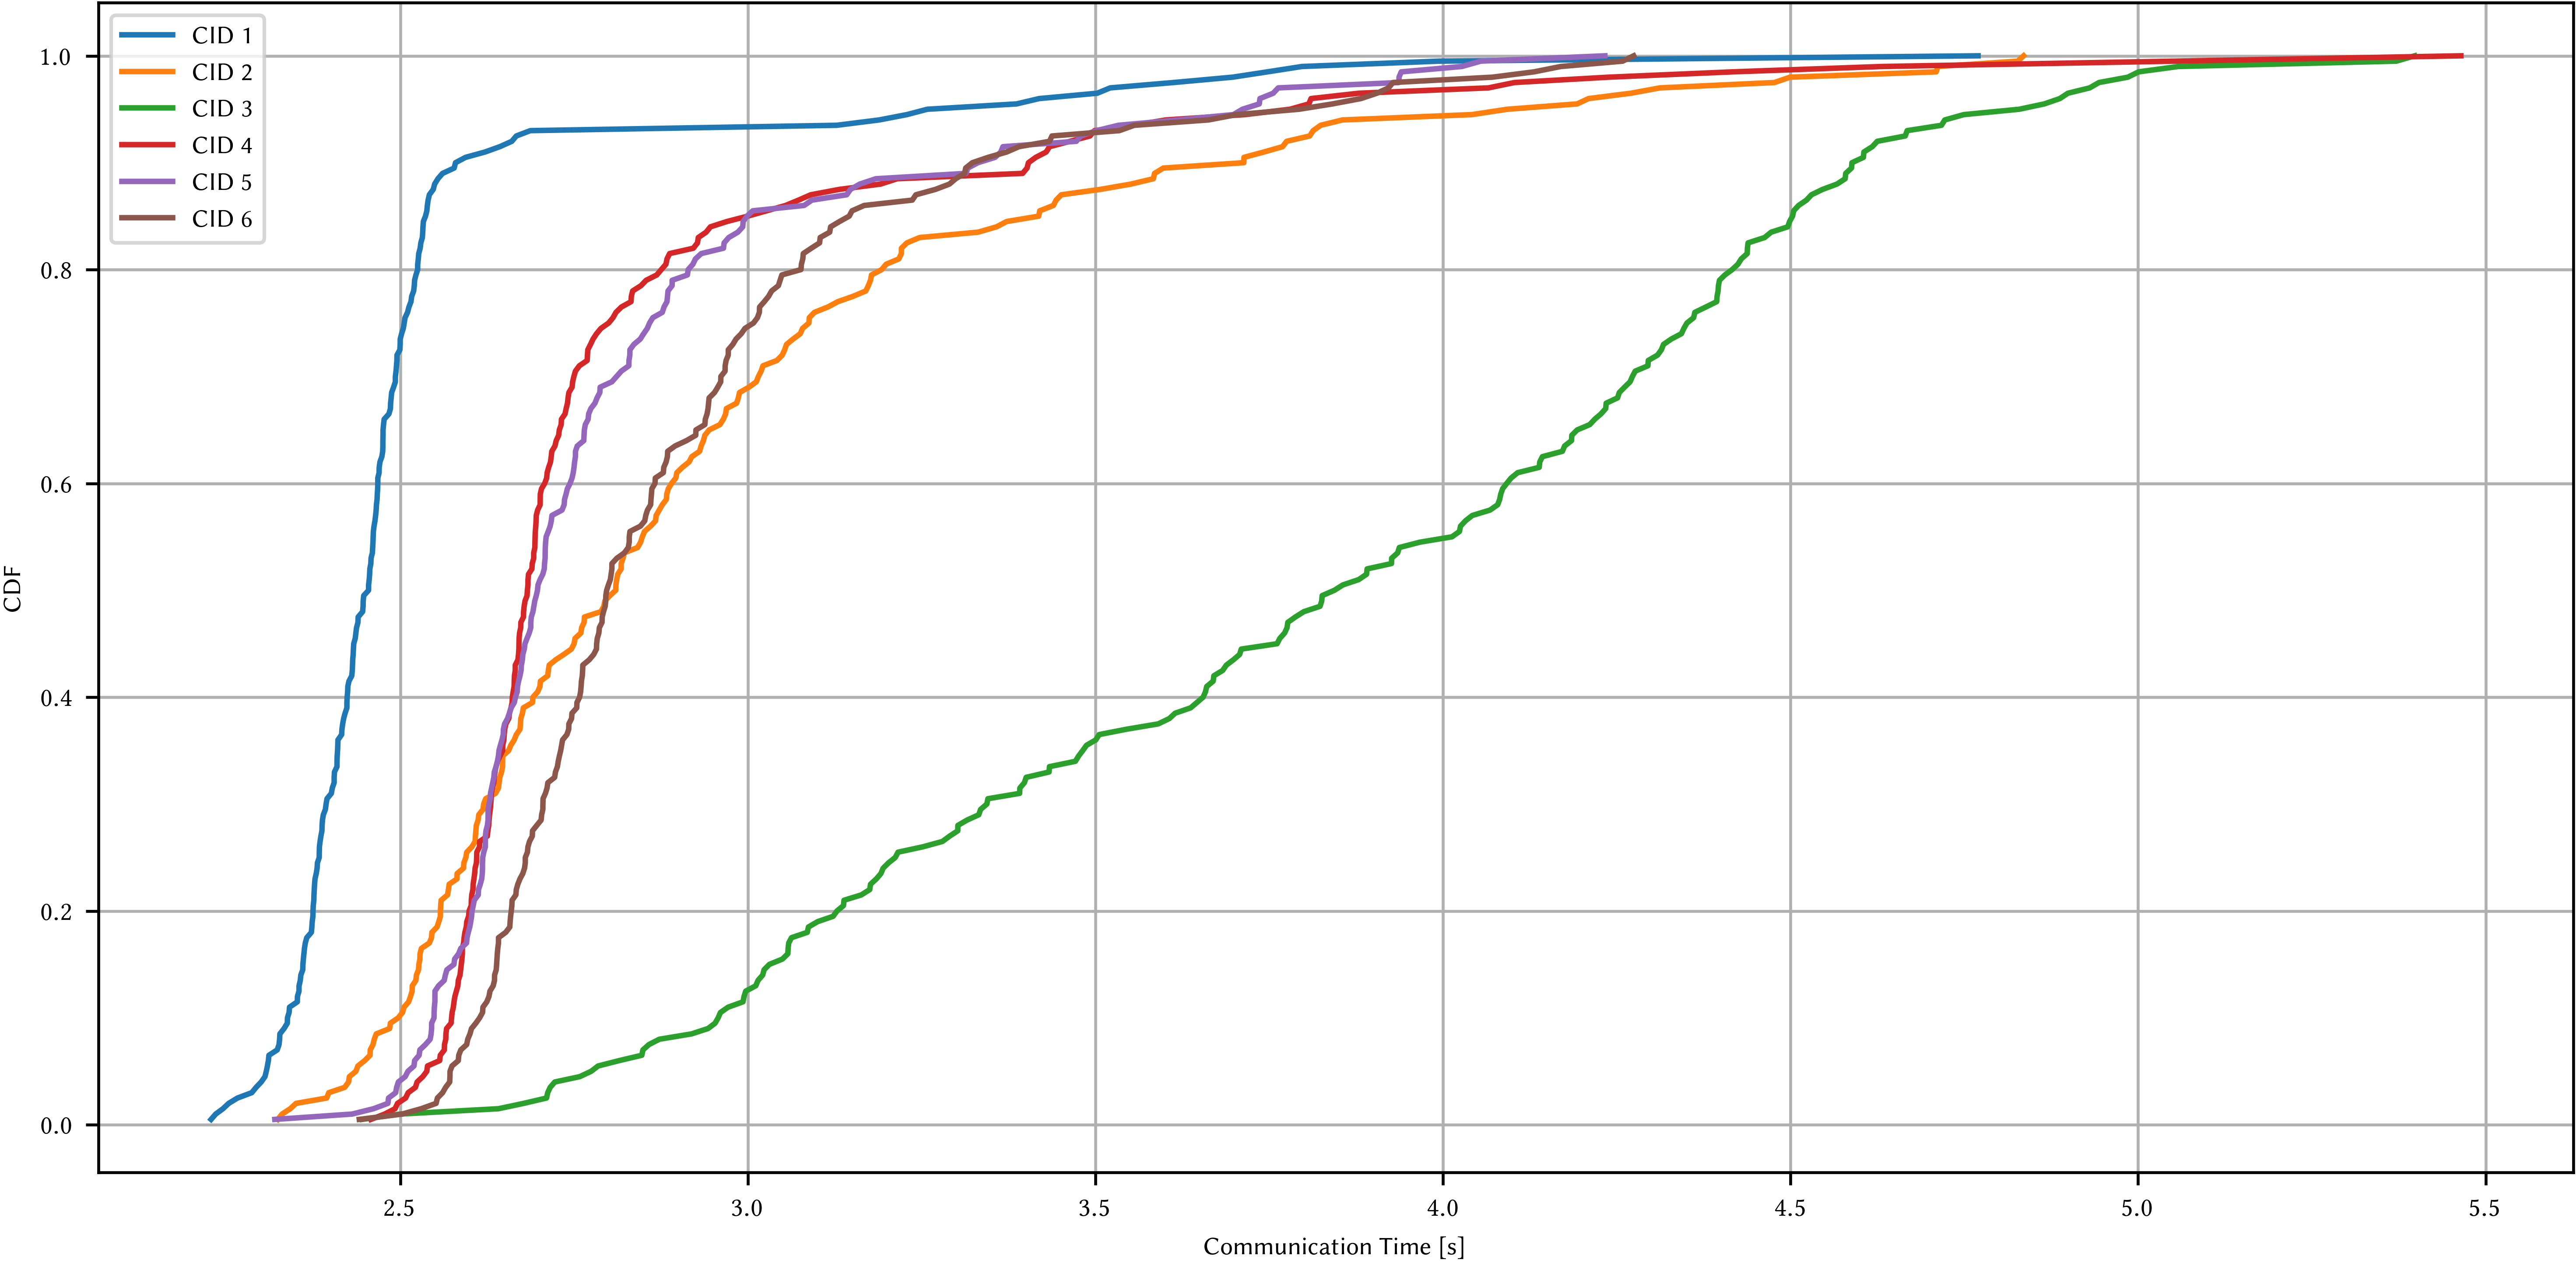

In [278]:
plt.figure(figsize=(10, 5))
for cid, group in per_round_cid.sort("cid").group_by("cid"):
    vals = group['total_comms'].sort().to_list()
    n = len(vals)
    plt.plot(vals, np.arange(1, n + 1) / n, label=f"CID {cid[0]}")

plt.xlabel(f"Communication Time [s]")
plt.ylabel("CDF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("comms_straggler_cdf_per_cid.pdf")
plt.show()